# 2025-26 Premier League Model — Post-Mortem

Walk-forward evaluation of the non-penalty Bayesian model across the full season.
Each gameweek re-fits on all data **before** that week, then predicts the actual scorelines.

**Primary lens: xG.** Goals are noisy (Poisson luck); xG is the underlying signal we care about.

Key questions:
1. How well does the model track xG vs raw goals?
2. Which teams does the model under/over-value — and why?
3. Is overshrinkage real?
4. What does the model genuinely do well?
5. Where does it fail, and what's the fix?

In [1]:
import sys, os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

_here = Path.cwd()
if not (_here / 'postmortem_2526.ipynb').exists():
    for _c in [_here / 'premier_league',
               _here / 'non_penalty_bayes' / 'premier_league',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT    = str(NOTEBOOK_DIR.parents[4])
DB_PATH      = os.path.join(REPO_ROOT, 'infra', 'data', 'db', 'fotmob.db')

plt.rcParams['font.family'] = 'monospace'
plt.rcParams['figure.dpi']  = 150
sns.set_style('whitegrid')
SEASON = '2025-2026'
print(f'DB: {DB_PATH}')

DB: /Users/admin/dev/algobetting/infra/data/db/fotmob.db


In [2]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("""
    SELECT gw, home_team, away_team,
           home_predicted, away_predicted,
           home_actual, away_actual,
           home_error, away_error,
           home_xg, away_xg,
           home_xg_error, away_xg_error
    FROM pl_match_predictions
    WHERE season = '2025-2026'
    ORDER BY gw, home_team
""", conn)

gw_acc = pd.read_sql("""
    SELECT gw, gw_start, matches, mae,
           home_actual, away_actual, total_actual,
           home_predicted, away_predicted, total_predicted
    FROM pl_gw_accuracy
    WHERE season = '2025-2026'
    ORDER BY gw
""", conn)
conn.close()

# Goals-based
df['home_bias']    = df['home_predicted'] - df['home_actual']
df['away_bias']    = df['away_predicted'] - df['away_actual']
df['total_pred']   = df['home_predicted'] + df['away_predicted']
df['total_actual'] = df['home_actual']   + df['away_actual']
df['total_bias']   = df['total_pred']    - df['total_actual']

# xG-based  (home_xg_error stored as pred - xg)
df['total_xg']     = df['home_xg'] + df['away_xg']
df['home_xg_abs']  = df['home_xg_error'].abs()
df['away_xg_abs']  = df['away_xg_error'].abs()

# Luck = how much did goals beat/miss xG?
df['home_luck']  = df['home_actual'] - df['home_xg']
df['away_luck']  = df['away_actual'] - df['away_xg']
df['total_luck'] = df['total_actual'] - df['total_xg']

print(f'Matches: {len(df)}   GWs: {df["gw"].nunique()}   xG coverage: {df["home_xg"].notna().sum()}/{ len(df)}')
df.head(3)

Matches: 330   GWs: 37   xG coverage: 330/330


,gw,home_team,away_team,home_predicted,away_predicted,home_actual,away_actual,home_error,away_error,home_xg,...,away_bias,total_pred,total_actual,total_bias,total_xg,home_xg_abs,away_xg_abs,home_luck,away_luck,total_luck
0,6,Aston Villa,Fulham,1.262853,1.258696,3.0,1.0,1.737147,0.258696,1.11,...,0.258696,2.521550,4.0,-1.478450,2.03,0.152853,0.338696,1.89,0.08,1.97
1,6,Brentford,Man United,1.506089,1.597407,3.0,1.0,1.493911,0.597407,2.02,...,0.597407,3.103496,4.0,-0.896504,4.10,0.513911,0.482593,0.98,-1.08,-0.10
2,6,Chelsea,Brighton,2.024583,1.219931,1.0,3.0,1.024583,1.780069,1.81,...,-1.780069,3.244514,4.0,-0.755486,4.09,0.214583,1.060069,-0.81,0.72,-0.09


## 1. Overall Summary

In [3]:
mae_goals = pd.concat([df['home_error'],   df['away_error']]).mean()
mae_xg    = pd.concat([df['home_xg_abs'], df['away_xg_abs']]).mean()
noise     = pd.concat([df['home_luck'].abs(), df['away_luck'].abs()]).mean()

summary = pd.DataFrame({
    'Metric': [
        '─── vs GOALS ───',
        'MAE (pred vs goals)', 'MAE home vs goals', 'MAE away vs goals',
        'Mean home bias (pred−actual)', 'Mean away bias',
        '─── vs xG (primary) ───',
        'MAE (pred vs xG)', 'MAE home vs xG', 'MAE away vs xG',
        '─── AVERAGES / game ───',
        'Actual goals home', 'Actual xG home', 'Predicted home',
        'Actual goals away', 'Actual xG away', 'Predicted away',
        'Irreducible noise |goals−xG|',
    ],
    'Value': [
        '—',
        round(mae_goals, 4),
        round(df['home_error'].mean(), 4),
        round(df['away_error'].mean(), 4),
        round(df['home_bias'].mean(), 4),
        round(df['away_bias'].mean(), 4),
        '—',
        round(mae_xg, 4),
        round(df['home_xg_abs'].mean(), 4),
        round(df['away_xg_abs'].mean(), 4),
        '—',
        round(df['home_actual'].mean(), 3),
        round(df['home_xg'].mean(), 3),
        round(df['home_predicted'].mean(), 3),
        round(df['away_actual'].mean(), 3),
        round(df['away_xg'].mean(), 3),
        round(df['away_predicted'].mean(), 3),
        round(noise, 4),
    ]
})
print(summary.to_string(index=False))

                      Metric   Value
            ─── vs GOALS ───       —
         MAE (pred vs goals)  0.8788
           MAE home vs goals  0.9412
           MAE away vs goals  0.8164
Mean home bias (pred−actual) -0.0467
              Mean away bias  0.0319
     ─── vs xG (primary) ───       —
            MAE (pred vs xG)  0.5695
              MAE home vs xG   0.597
              MAE away vs xG   0.542
     ─── AVERAGES / game ───       —
           Actual goals home   1.548
              Actual xG home    1.57
              Predicted home   1.502
           Actual goals away   1.242
              Actual xG away   1.264
              Predicted away   1.274
Irreducible noise |goals−xG|  0.7899


## 2. Goals vs xG — The Noise the Model Is Fighting

xG measures the quality of chances created; goals adds a large Poisson random component on top.
A model that predicts *underlying threat* well will look worse vs goals than vs xG.
The gap between the two MAEs is **irreducible noise** — no model can predict it.

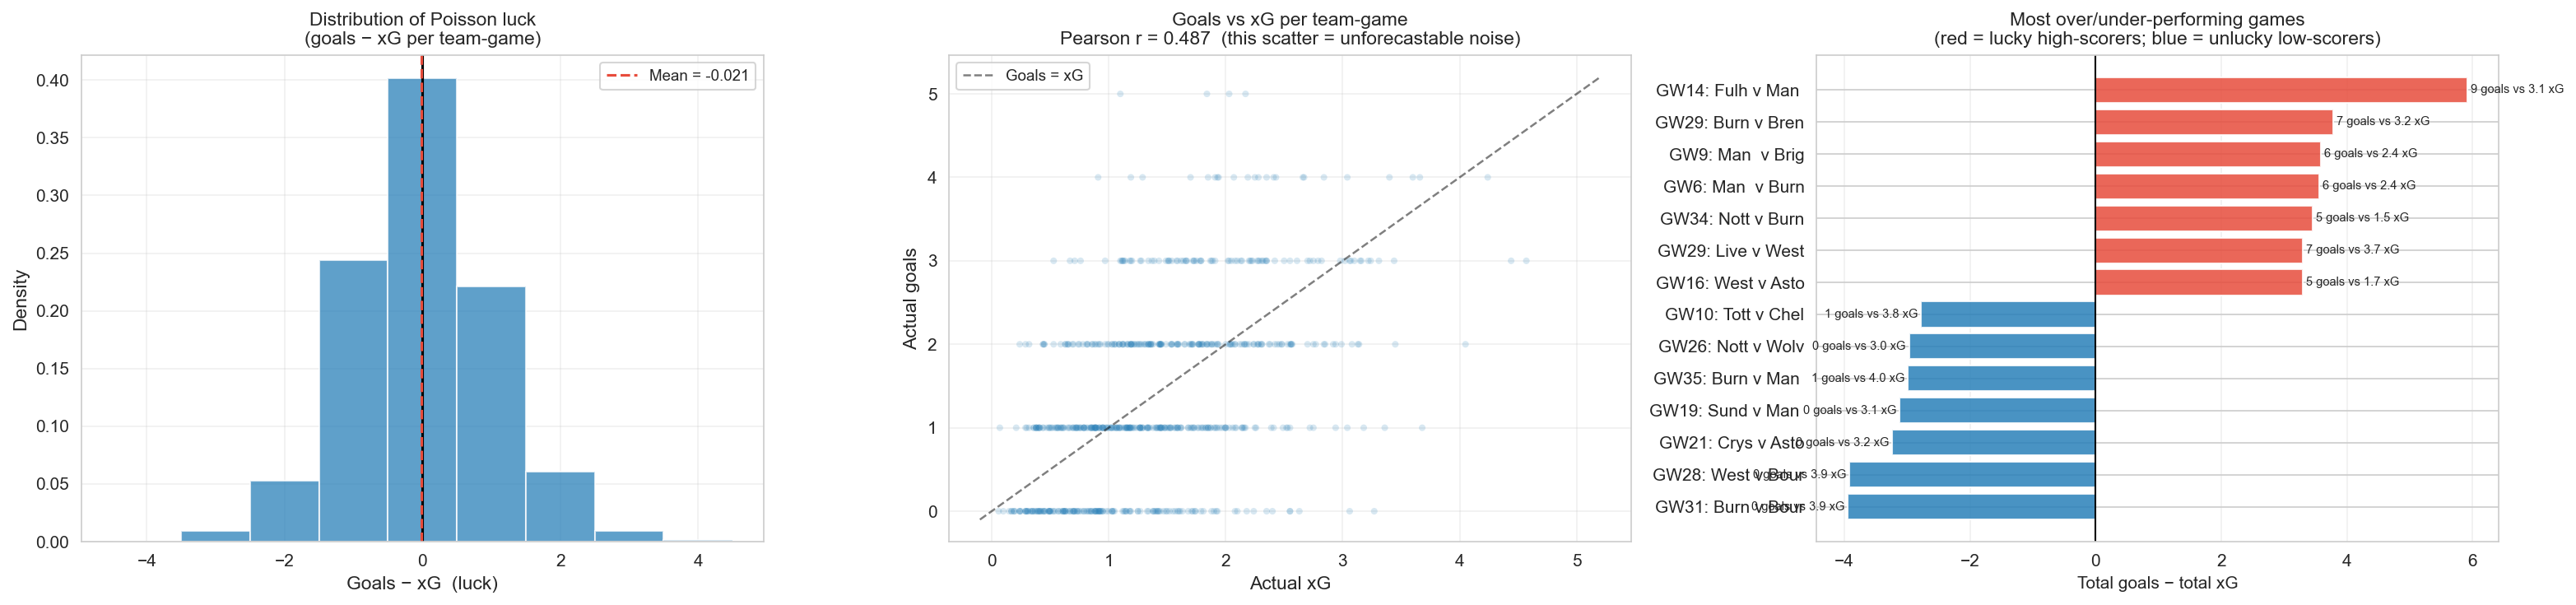

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Left: distribution of per-team-game luck
ax = axes[0]
luck_all = pd.concat([df['home_luck'], df['away_luck']])
bins = np.arange(-4.5, 5.5, 1)
ax.hist(luck_all, bins=bins, color='#2980b9', alpha=0.75, edgecolor='white', density=True)
ax.axvline(0, color='black', linewidth=1.5)
ax.axvline(luck_all.mean(), color='#e74c3c', linewidth=1.5, linestyle='--',
           label=f'Mean = {luck_all.mean():+.3f}')
ax.set_xlabel('Goals − xG  (luck)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Distribution of Poisson luck\n(goals − xG per team-game)', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Middle: goals vs xG scatter — the noise the model fights
ax2 = axes[1]
all_goals = pd.concat([df['home_actual'], df['away_actual']])
all_xg    = pd.concat([df['home_xg'],     df['away_xg']])
ax2.scatter(all_xg, all_goals, alpha=0.18, s=15, color='#2980b9', edgecolors='none')
lo, hi = -0.1, all_goals.max() + 0.2
ax2.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.5, label='Goals = xG')
r_gx = np.corrcoef(all_xg, all_goals)[0, 1]
ax2.set_xlabel('Actual xG', fontsize=11); ax2.set_ylabel('Actual goals', fontsize=11)
ax2.set_title(f'Goals vs xG per team-game\nPearson r = {r_gx:.3f}  (this scatter = unforecastable noise)', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# Right: luckiest & unluckiest matches by total goals-xG
df['luck_label'] = 'GW' + df['gw'].astype(str) + ': ' + df['home_team'].str[:4] + ' v ' + df['away_team'].str[:4]
extremes = pd.concat([df.nlargest(7, 'total_luck'), df.nsmallest(7, 'total_luck')]).sort_values('total_luck')
ax3 = axes[2]
cols3 = ['#e74c3c' if x > 0 else '#2980b9' for x in extremes['total_luck']]
ax3.barh(extremes['luck_label'], extremes['total_luck'], color=cols3, edgecolor='white', alpha=0.85)
ax3.axvline(0, color='black', lw=1)
for i, (_, row) in enumerate(extremes.iterrows()):
    label = f'{int(row.total_actual)} goals vs {row.total_xg:.1f} xG'
    ax3.text(row.total_luck + (0.05 if row.total_luck > 0 else -0.05), i,
             label, va='center', ha='left' if row.total_luck > 0 else 'right', fontsize=7)
ax3.set_xlabel('Total goals − total xG', fontsize=10)
ax3.set_title('Most over/under-performing games\n(red = lucky high-scorers; blue = unlucky low-scorers)', fontsize=11)
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/postmortem_xg_luck.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Model Calibration: Predictions vs xG vs Goals

The key question: does the model track the *underlying chance quality* (xG) well?
A tight fit to xG with a looser fit to goals is the correct pattern for a well-specified model.

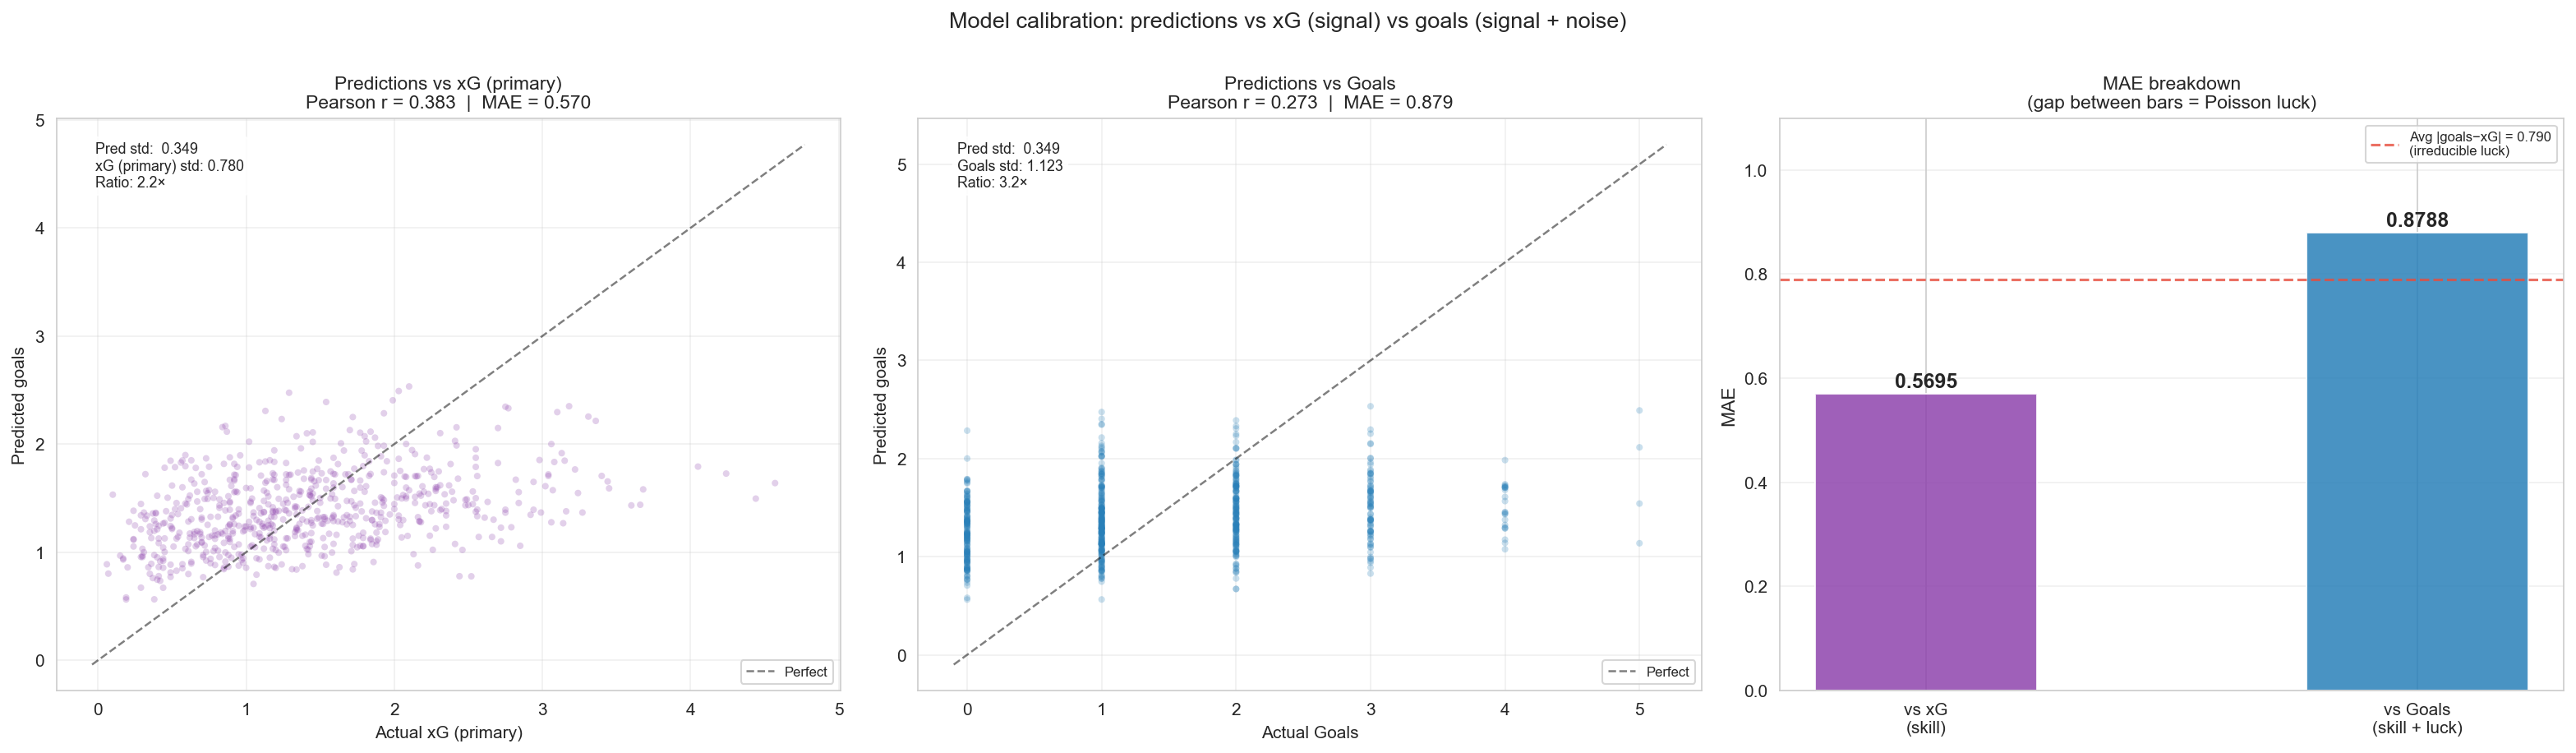

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

all_pred  = pd.concat([df['home_predicted'], df['away_predicted']])
all_xg    = pd.concat([df['home_xg'],        df['away_xg']])
all_goals = pd.concat([df['home_actual'],    df['away_actual']])

def cal_scatter(ax, pred, bench, label, color):
    ax.scatter(bench, pred, alpha=0.25, s=15, color=color, edgecolors='none')
    lo = min(bench.min(), pred.min()) - 0.1
    hi = max(bench.max(), pred.max()) + 0.2
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.5, label='Perfect')
    r   = np.corrcoef(bench, pred)[0, 1]
    mae = (pred - bench).abs().mean()
    ax.set_xlabel(f'Actual {label}', fontsize=10)
    ax.set_ylabel('Predicted goals', fontsize=10)
    ax.set_title(f'Predictions vs {label}\nPearson r = {r:.3f}  |  MAE = {mae:.3f}', fontsize=11)
    ax.text(0.05, 0.88,
            f'Pred std:  {pred.std():.3f}\n{label} std: {bench.std():.3f}\nRatio: {bench.std()/pred.std():.1f}×',
            transform=ax.transAxes, fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

cal_scatter(axes[0], all_pred, all_xg,    'xG (primary)',  '#8e44ad')
cal_scatter(axes[1], all_pred, all_goals, 'Goals',         '#2980b9')

# Right: MAE bar comparison
mae_vals = {
    'vs xG\n(skill)':            pd.concat([df['home_xg_abs'], df['away_xg_abs']]).mean(),
    'vs Goals\n(skill + luck)':  pd.concat([df['home_error'],  df['away_error']]).mean(),
}
noise_floor = pd.concat([df['home_luck'].abs(), df['away_luck'].abs()]).mean()

ax3 = axes[2]
bars = ax3.bar(list(mae_vals.keys()), list(mae_vals.values()),
               color=['#8e44ad','#2980b9'], edgecolor='white', alpha=0.85, width=0.45)
for bar, v in zip(bars, mae_vals.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax3.axhline(noise_floor, color='#e74c3c', linestyle='--', alpha=0.8,
            label=f'Avg |goals−xG| = {noise_floor:.3f}\n(irreducible luck)')
ax3.set_ylabel('MAE', fontsize=11)
ax3.set_title('MAE breakdown\n(gap between bars = Poisson luck)', fontsize=11)
ax3.set_ylim(0, list(mae_vals.values())[-1] * 1.25)
ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

plt.suptitle('Model calibration: predictions vs xG (signal) vs goals (signal + noise)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/postmortem_calibration_xg.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Per-Team: Under/Over Valuation, Shrinkage & xG Luck

In [6]:
home_s = df[['home_team','home_predicted','home_actual','home_xg',
             'away_predicted','away_actual','away_xg']].rename(
    columns={'home_team':'team','home_predicted':'sc_pred','home_actual':'sc_actual',
             'home_xg':'sc_xg','away_predicted':'co_pred','away_actual':'co_actual','away_xg':'co_xg'})
away_s = df[['away_team','away_predicted','away_actual','away_xg',
             'home_predicted','home_actual','home_xg']].rename(
    columns={'away_team':'team','away_predicted':'sc_pred','away_actual':'sc_actual',
             'away_xg':'sc_xg','home_predicted':'co_pred','home_actual':'co_actual','home_xg':'co_xg'})
combined = pd.concat([home_s, away_s], ignore_index=True)
combined['sc_bias']    = combined['sc_pred'] - combined['sc_actual']
combined['sc_xg_bias'] = combined['sc_pred'] - combined['sc_xg']
combined['xg_luck']    = combined['sc_actual'] - combined['sc_xg']
combined['co_bias']    = combined['co_pred'] - combined['co_actual']
combined['co_xg_bias'] = combined['co_pred'] - combined['co_xg']

team_stats = combined.groupby('team').agg(
    n          = ('sc_actual','count'),
    sc_actual  = ('sc_actual','mean'),
    sc_xg      = ('sc_xg',    'mean'),
    sc_pred    = ('sc_pred',  'mean'),
    sc_bias    = ('sc_bias',  'mean'),
    sc_xg_bias = ('sc_xg_bias','mean'),
    xg_luck    = ('xg_luck',  'mean'),
    co_actual  = ('co_actual','mean'),
    co_xg      = ('co_xg',   'mean'),
    co_pred    = ('co_pred', 'mean'),
    co_bias    = ('co_bias', 'mean'),
    co_xg_bias = ('co_xg_bias','mean'),
).round(3).sort_values('sc_xg')

# Shrinkage correlations
corr_g, pval_g = spearmanr(team_stats['sc_actual'], team_stats['sc_bias'])
corr_x, pval_x = spearmanr(team_stats['sc_xg'],     team_stats['sc_xg_bias'])
print(f'Shrinkage vs goals:  Spearman r = {corr_g:.3f}  (p={pval_g:.4f})')
print(f'Shrinkage vs xG:     Spearman r = {corr_x:.3f}  (p={pval_x:.4f})')
print()
print('sc = scoring side (goals, xG, prediction).  co = conceding side')
print('xg_luck = goals − xG (positive = over-performed xG)')
team_stats[['sc_xg','sc_actual','sc_pred','sc_xg_bias','sc_bias','xg_luck','co_xg','co_actual','co_pred']]

Shrinkage vs goals:  Spearman r = -0.597  (p=0.0055)
Shrinkage vs xG:     Spearman r = -0.479  (p=0.0326)

sc = scoring side (goals, xG, prediction).  co = conceding side
xg_luck = goals − xG (positive = over-performed xG)


,sc_xg,sc_actual,sc_pred,sc_xg_bias,sc_bias,xg_luck,co_xg,co_actual,co_pred
team,,,,,,,,,
Burnley,0.861,1.000,0.960,0.099,-0.040,0.139,1.957,2.030,1.846
Wolves,0.943,0.727,1.015,0.073,0.288,-0.215,1.543,1.697,1.644
Sunderland,1.020,1.091,0.957,-0.063,-0.134,0.071,1.483,1.333,1.457
Tottenham,1.031,1.152,1.327,0.297,0.176,0.121,1.402,1.636,1.486
Everton,1.199,1.242,1.226,0.027,-0.016,0.043,1.497,1.364,1.375
West Ham,1.247,1.242,1.168,-0.079,-0.075,-0.005,1.571,1.576,1.690
Nottm Forest,1.248,1.303,1.239,-0.009,-0.064,0.055,1.490,1.273,1.431
Fulham,1.302,1.242,1.290,-0.013,0.047,-0.060,1.402,1.394,1.362
Aston Villa,1.342,1.667,1.385,0.043,-0.281,0.325,1.375,1.333,1.349


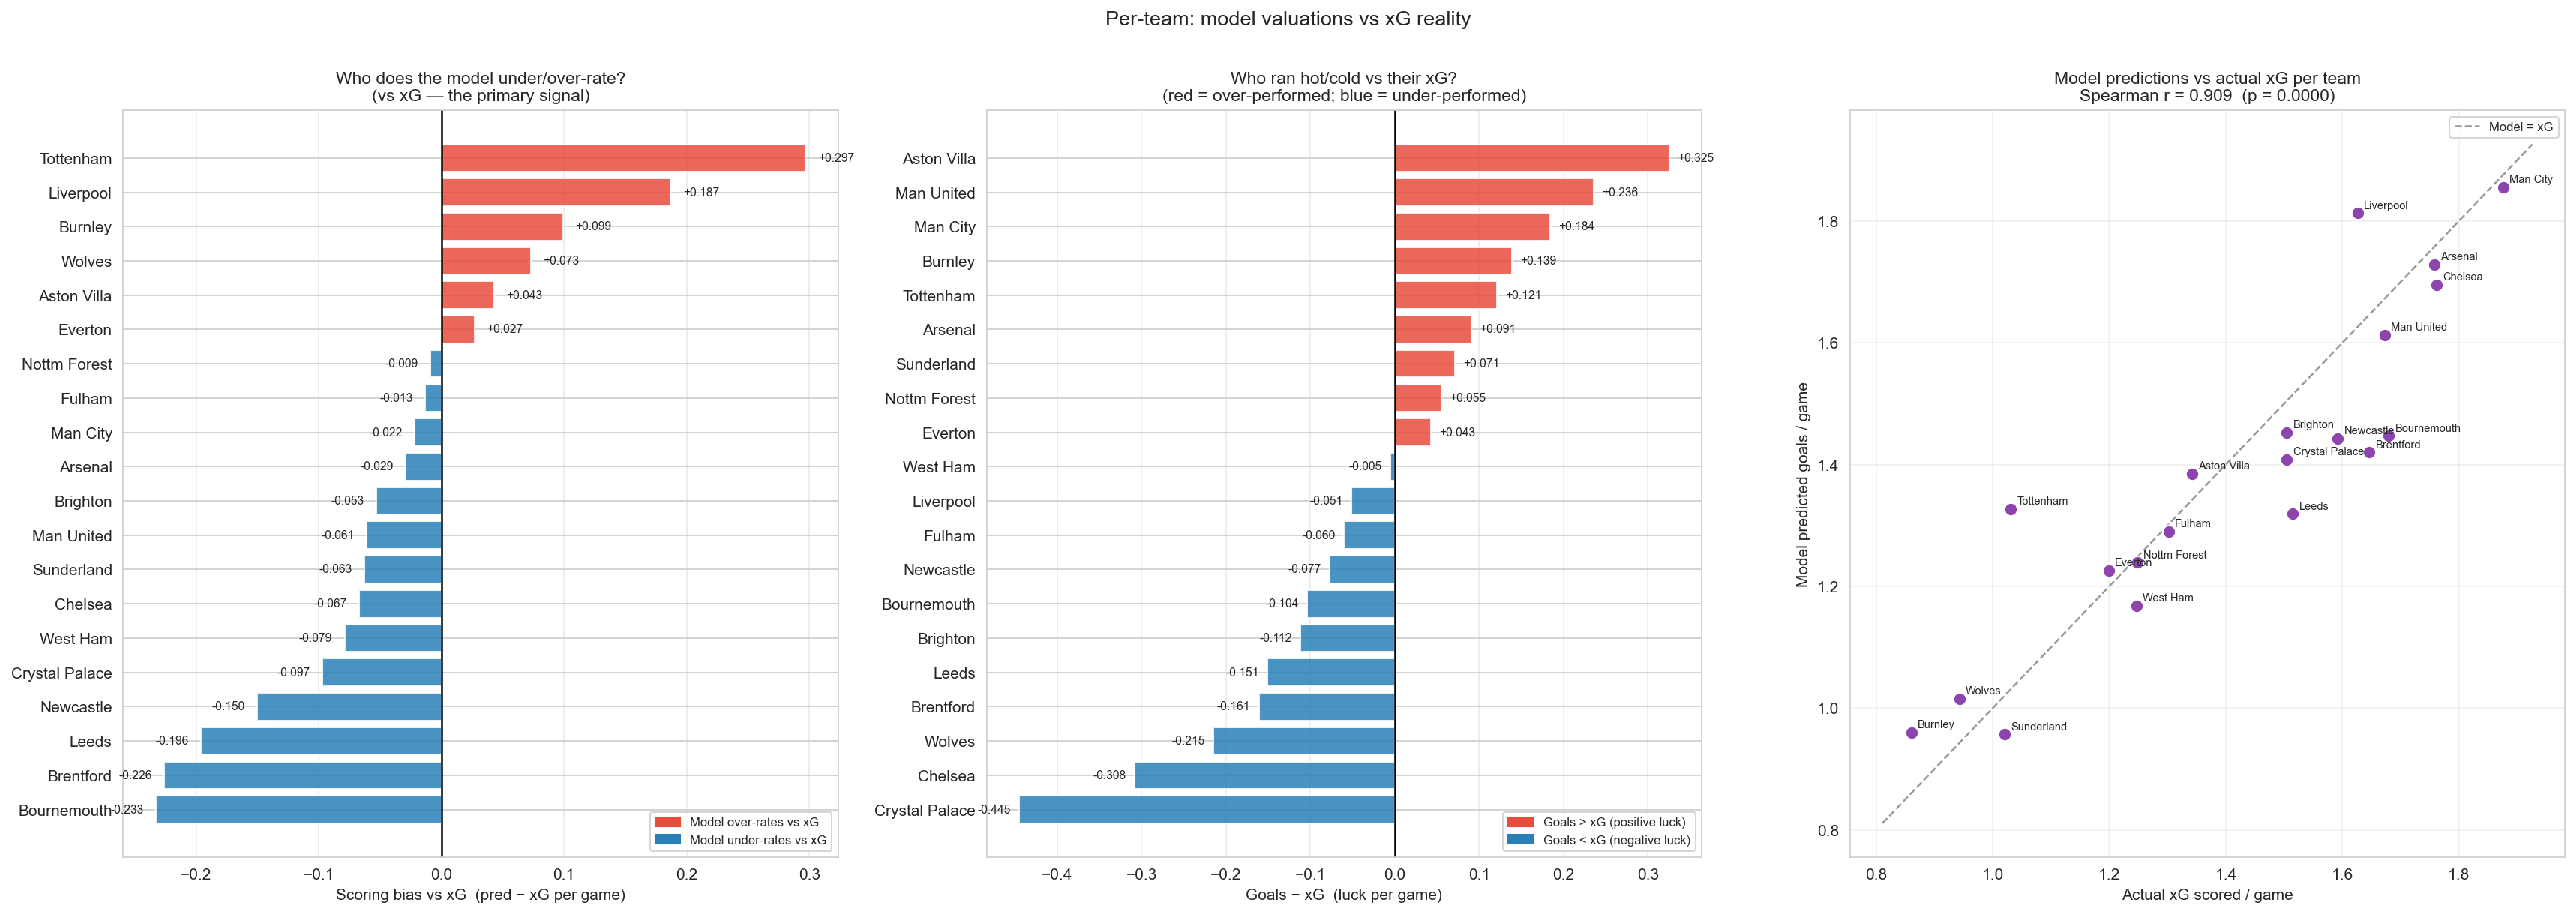

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(23, 8))

ts_xg   = team_stats.sort_values('sc_xg_bias')
ts_luck = team_stats.sort_values('xg_luck')

# Panel 1: model bias vs xG (primary) ─────────────────────────────────────────
ax = axes[0]
colors_x = ['#e74c3c' if b > 0 else '#2980b9' for b in ts_xg['sc_xg_bias']]
bars = ax.barh(ts_xg.index, ts_xg['sc_xg_bias'], color=colors_x, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=1.2)
for bar, val in zip(bars, ts_xg['sc_xg_bias']):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=7.5)
ax.set_xlabel('Scoring bias vs xG  (pred − xG per game)', fontsize=10)
ax.set_title('Who does the model under/over-rate?\n(vs xG — the primary signal)', fontsize=11)
red_p  = mpatches.Patch(color='#e74c3c', label='Model over-rates vs xG')
blue_p = mpatches.Patch(color='#2980b9', label='Model under-rates vs xG')
ax.legend(handles=[red_p, blue_p], fontsize=8, loc='lower right')
ax.grid(axis='x', alpha=0.4)

# Panel 2: xG luck per team ────────────────────────────────────────────────────
ax2 = axes[1]
colors_l = ['#e74c3c' if b > 0 else '#2980b9' for b in ts_luck['xg_luck']]
bars2 = ax2.barh(ts_luck.index, ts_luck['xg_luck'], color=colors_l, edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', lw=1.2)
for bar, val in zip(bars2, ts_luck['xg_luck']):
    ax2.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=7.5)
ax2.set_xlabel('Goals − xG  (luck per game)', fontsize=10)
ax2.set_title('Who ran hot/cold vs their xG?\n(red = over-performed; blue = under-performed)', fontsize=11)
red_p2  = mpatches.Patch(color='#e74c3c', label='Goals > xG (positive luck)')
blue_p2 = mpatches.Patch(color='#2980b9', label='Goals < xG (negative luck)')
ax2.legend(handles=[red_p2, blue_p2], fontsize=8, loc='lower right')
ax2.grid(axis='x', alpha=0.4)

# Panel 3: scatter — model predictions vs actual xG ───────────────────────────
ax3 = axes[2]
ax3.scatter(team_stats['sc_xg'], team_stats['sc_pred'], s=70, color='#8e44ad',
            edgecolors='white', zorder=3)
for team, row in team_stats.iterrows():
    ax3.annotate(team, (row['sc_xg'], row['sc_pred']),
                 textcoords='offset points', xytext=(4, 3), fontsize=7)
lo3 = min(team_stats['sc_xg'].min(), team_stats['sc_pred'].min()) - 0.05
hi3 = max(team_stats['sc_xg'].max(), team_stats['sc_pred'].max()) + 0.05
ax3.plot([lo3, hi3], [lo3, hi3], 'k--', alpha=0.4, lw=1.2, label='Model = xG')
r3, p3 = spearmanr(team_stats['sc_xg'], team_stats['sc_pred'])
ax3.set_xlabel('Actual xG scored / game', fontsize=10)
ax3.set_ylabel('Model predicted goals / game', fontsize=10)
ax3.set_title(f'Model predictions vs actual xG per team\nSpearman r = {r3:.3f}  (p = {p3:.4f})', fontsize=11)
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

plt.suptitle('Per-team: model valuations vs xG reality', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/postmortem_team_xg.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Overshrinkage — Confirmed

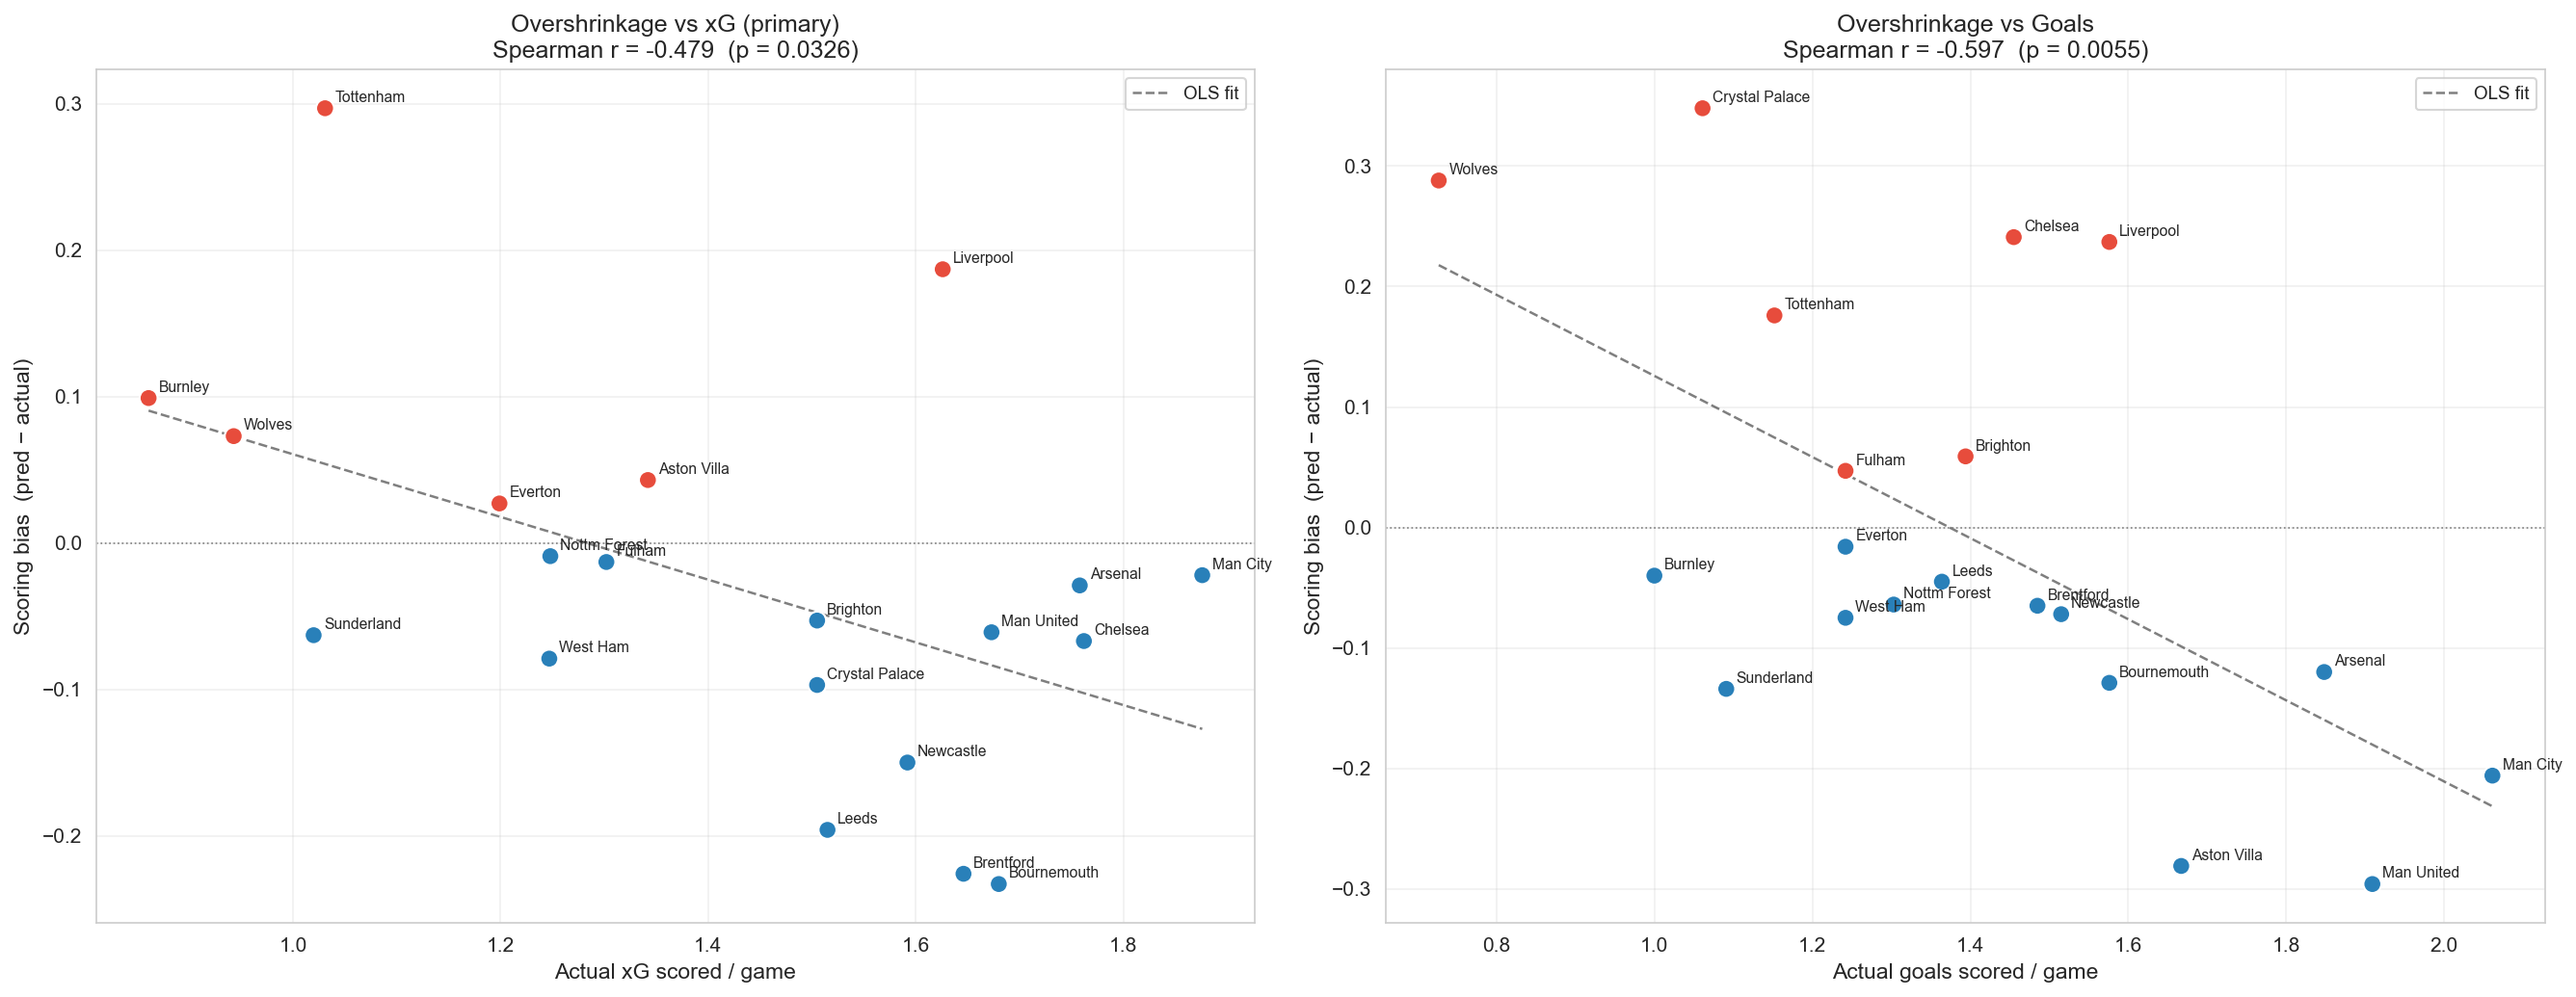

Negative slope = model pulls strong teams down and weak teams up = overshrinkage confirmed.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, x_col, bias_col, title, xlabel in [
    (axes[0], 'sc_xg',     'sc_xg_bias', 'vs xG (primary)',   'Actual xG scored / game'),
    (axes[1], 'sc_actual', 'sc_bias',    'vs Goals',          'Actual goals scored / game'),
]:
    corr, pval = spearmanr(team_stats[x_col], team_stats[bias_col])
    ax.scatter(team_stats[x_col], team_stats[bias_col],
               color=['#e74c3c' if b > 0 else '#2980b9' for b in team_stats[bias_col]],
               s=80, edgecolors='white', zorder=3)
    for team, row in team_stats.iterrows():
        ax.annotate(team, (row[x_col], row[bias_col]),
                    textcoords='offset points', xytext=(5, 3), fontsize=7.5)
    m, b = np.polyfit(team_stats[x_col], team_stats[bias_col], 1)
    xs = np.linspace(team_stats[x_col].min(), team_stats[x_col].max(), 100)
    ax.plot(xs, m*xs + b, 'k--', alpha=0.5, lw=1.2, label=f'OLS fit')
    ax.axhline(0, color='gray', lw=0.8, linestyle=':')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Scoring bias  (pred − actual)', fontsize=11)
    ax.set_title(f'Overshrinkage {title}\nSpearman r = {corr:.3f}  (p = {pval:.4f})', fontsize=12)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/postmortem_shrinkage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Negative slope = model pulls strong teams down and weak teams up = overshrinkage confirmed.')

## 6. What the Model Does Well

Even with shrinkage, a good model should correctly *rank* teams and identify match favourites.
This section measures that directly.

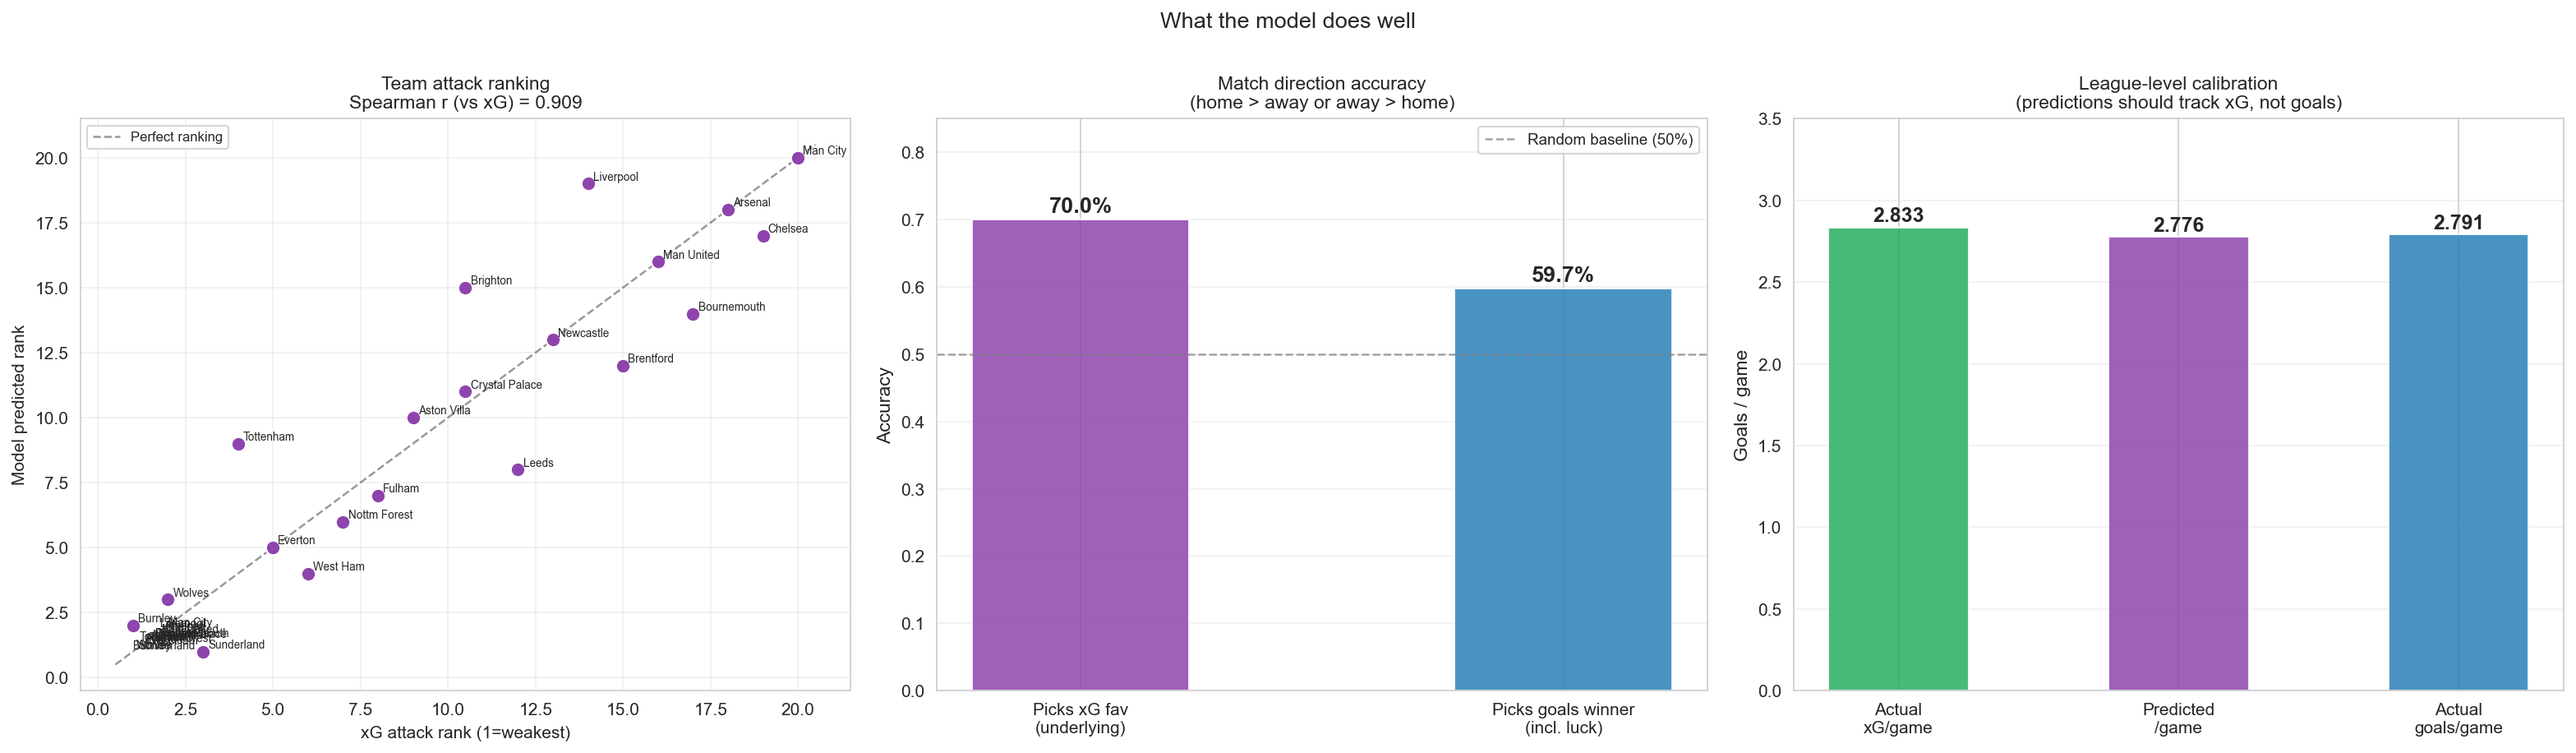

Attack ranking (vs xG):   r = 0.909
Attack ranking (vs goals): r = 0.823
Defence ranking (vs xG):  r = 0.712
Direction accuracy vs xG:     70.0%
Direction accuracy vs goals:  59.7%  (includes luck)


In [9]:
# Team ranking quality
r_sc_goals,  _ = spearmanr(team_stats['sc_actual'], team_stats['sc_pred'])
r_sc_xg,     _ = spearmanr(team_stats['sc_xg'],     team_stats['sc_pred'])
r_co_goals,  _ = spearmanr(team_stats['co_actual'], team_stats['co_pred'])
r_co_xg,     _ = spearmanr(team_stats['co_xg'],     team_stats['co_pred'])

# Match-level direction accuracy
df['pred_home_fav']  = df['home_predicted'] > df['away_predicted']
df['xg_home_fav']   = df['home_xg']  > df['away_xg']
df['goal_home_fav'] = df['home_actual'] > df['away_actual']
draws_g = (df['home_actual'] == df['away_actual']).sum()
draws_x = (df['home_xg']    == df['away_xg']).sum()

dir_xg   = (df['pred_home_fav'] == df['xg_home_fav']).mean()
dir_goal = (df['pred_home_fav'] == df['goal_home_fav']).mean()

# League-level calibration
avg_pred  = df['total_pred'].mean()
avg_xg    = df['total_xg'].mean()
avg_goals = df['total_actual'].mean()

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Left: team rank scatter — model vs xG
ax = axes[0]
ax.scatter(team_stats['sc_xg'].rank(), team_stats['sc_pred'].rank(),
           s=70, color='#8e44ad', edgecolors='white', zorder=3)
for team, row in team_stats.iterrows():
    ax.annotate(team, (row['sc_xg']+0, row['sc_pred']+0),
                textcoords='offset points', xytext=(3, 2), fontsize=6.5)
# Actually rank them
xg_rank   = team_stats['sc_xg'].rank()
pred_rank = team_stats['sc_pred'].rank()
ax.scatter(xg_rank, pred_rank, s=70, color='#8e44ad', edgecolors='white', zorder=3)
for team, row in team_stats.iterrows():
    ax.annotate(team, (xg_rank[team], pred_rank[team]),
                textcoords='offset points', xytext=(3,2), fontsize=6.5)
lo_r, hi_r = 0.5, len(team_stats) + 0.5
ax.plot([lo_r, hi_r],[lo_r, hi_r],'k--',alpha=0.4,lw=1.2,label='Perfect ranking')
ax.set_xlabel('xG attack rank (1=weakest)', fontsize=10)
ax.set_ylabel('Model predicted rank', fontsize=10)
ax.set_title(f'Team attack ranking\nSpearman r (vs xG) = {r_sc_xg:.3f}', fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Middle: direction accuracy bars
ax2 = axes[1]
labels  = ['Picks xG fav\n(underlying)', 'Picks goals winner\n(incl. luck)']
heights = [dir_xg, dir_goal]
colors2 = ['#8e44ad', '#2980b9']
bs = ax2.bar(labels, heights, color=colors2, edgecolor='white', alpha=0.85, width=0.45)
ax2.axhline(0.5, color='gray', linestyle='--', lw=1.2, alpha=0.7, label='Random baseline (50%)')
for bar, h in zip(bs, heights):
    ax2.text(bar.get_x()+bar.get_width()/2, h+0.005, f'{h:.1%}',
             ha='center', va='bottom', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 0.85)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Match direction accuracy\n(home > away or away > home)', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

# Right: league-level total goals calibration
ax3 = axes[2]
categories  = ['Actual\nxG/game', 'Predicted\n/game', 'Actual\ngoals/game']
vals        = [avg_xg, avg_pred, avg_goals]
bar_colors  = ['#27ae60', '#8e44ad', '#2980b9']
bs3 = ax3.bar(categories, vals, color=bar_colors, edgecolor='white', alpha=0.85, width=0.5)
for bar, v in zip(bs3, vals):
    ax3.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
ax3.set_ylabel('Goals / game', fontsize=11)
ax3.set_ylim(0, 3.5)
ax3.set_title('League-level calibration\n(predictions should track xG, not goals)', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('What the model does well', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/postmortem_strengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Attack ranking (vs xG):   r = {r_sc_xg:.3f}')
print(f'Attack ranking (vs goals): r = {r_sc_goals:.3f}')
print(f'Defence ranking (vs xG):  r = {r_co_xg:.3f}')
print(f'Direction accuracy vs xG:     {dir_xg:.1%}')
print(f'Direction accuracy vs goals:  {dir_goal:.1%}  (includes luck)')

## 7. Variance Compression — The Model's Biggest Weakness

In [10]:
std_table = pd.DataFrame({
    'Metric':        ['Home', 'Away', 'Total'],
    'Actual goals std': [
        df['home_actual'].std(), df['away_actual'].std(), df['total_actual'].std()],
    'Actual xG std': [
        df['home_xg'].std(), df['away_xg'].std(), df['total_xg'].std()],
    'Predicted std': [
        df['home_predicted'].std(), df['away_predicted'].std(), df['total_pred'].std()],
}).round(4)
std_table['Compression vs goals'] = (std_table['Actual goals std'] / std_table['Predicted std']).round(2)
std_table['Compression vs xG']    = (std_table['Actual xG std']    / std_table['Predicted std']).round(2)
print('Variance compression:')
print(std_table.to_string(index=False))
print()
print('Even vs xG (which has lower variance than goals), predictions are still compressed.')
print('This points to Bayesian shrinkage + tight priors, not just Poisson noise.')

Variance compression:
Metric  Actual goals std  Actual xG std  Predicted std  Compression vs goals  Compression vs xG
  Home            1.1640         0.7976         0.3564                  3.27               2.24
  Away            1.0613         0.7308         0.3014                  3.52               2.42
 Total            1.5638         1.0082         0.2740                  5.71               3.68

Even vs xG (which has lower variance than goals), predictions are still compressed.
This points to Bayesian shrinkage + tight priors, not just Poisson noise.


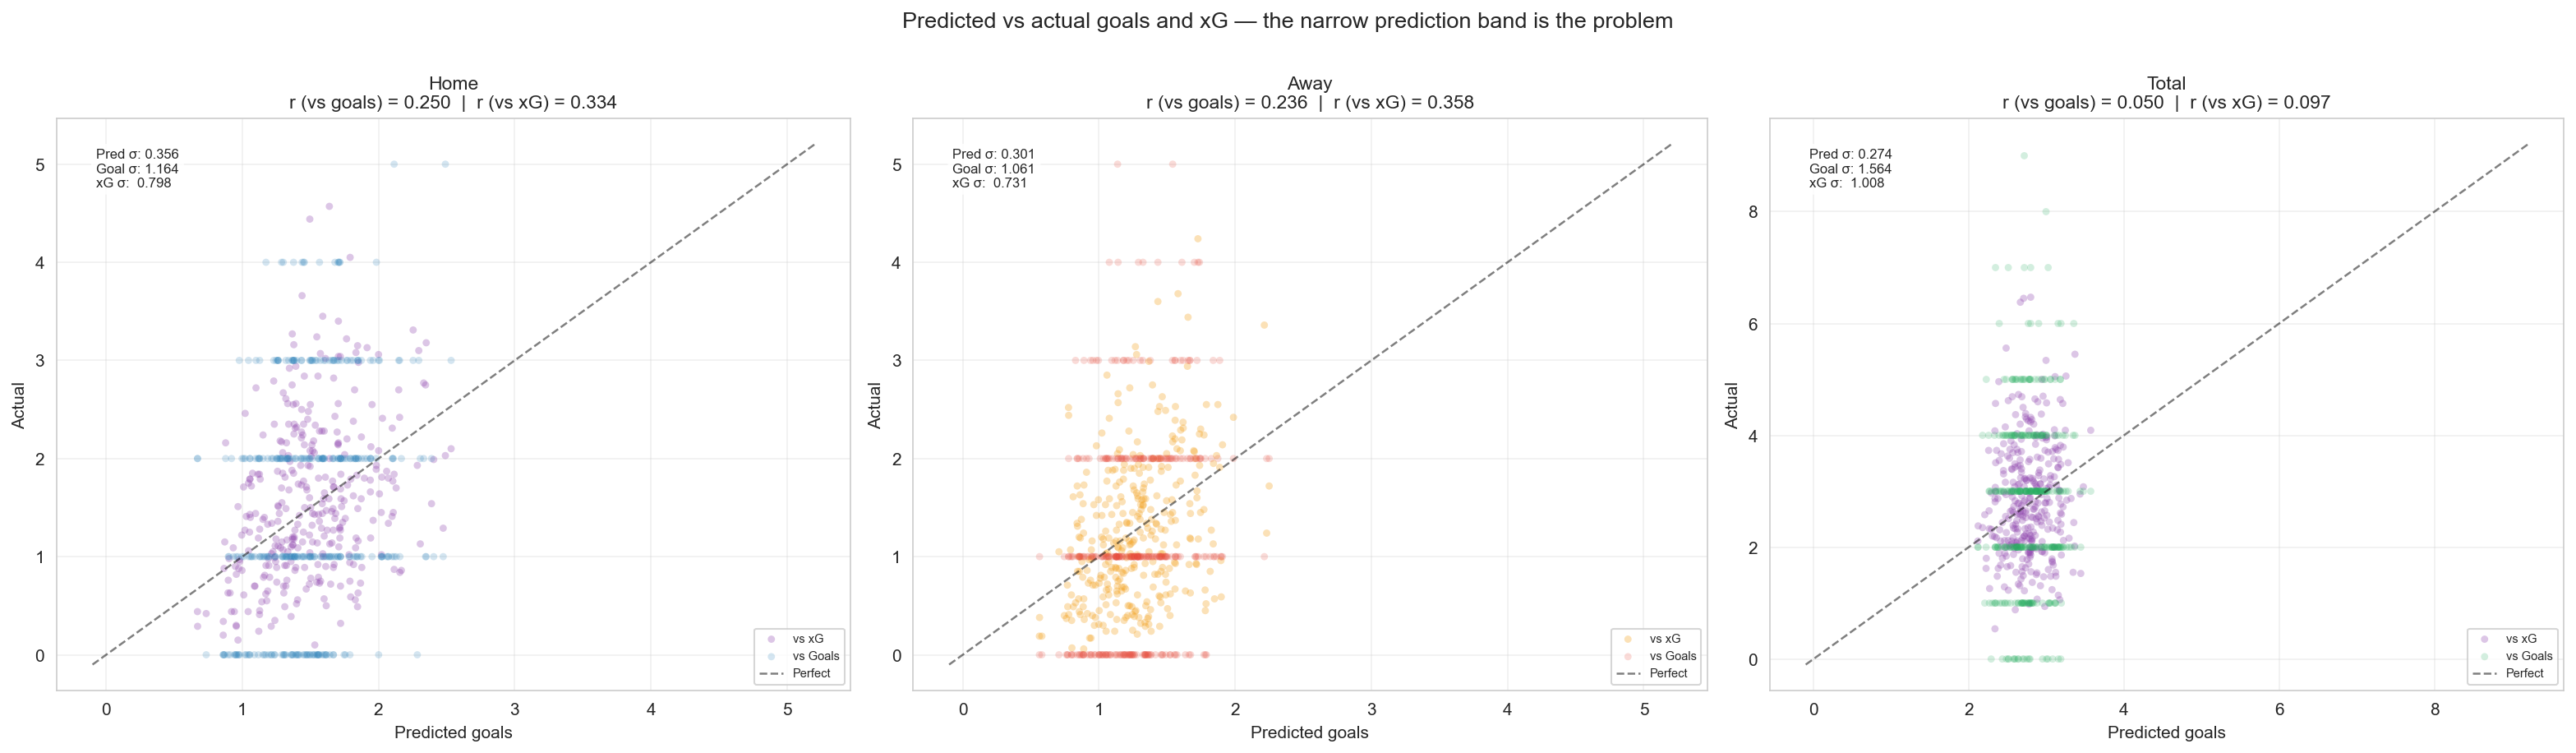

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

def scatter_both(ax, pred, actual, xg, title, color_g, color_x):
    ax.scatter(pred, xg,     alpha=0.3, s=18, color=color_x, edgecolors='none', label='vs xG')
    ax.scatter(pred, actual, alpha=0.2, s=18, color=color_g, edgecolors='none', label='vs Goals')
    lo = min(pred.min(), actual.min(), xg.min()) - 0.1
    hi = max(pred.max(), actual.max(), xg.max()) + 0.2
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.5, label='Perfect')
    r_g = np.corrcoef(pred, actual)[0, 1]
    r_x = np.corrcoef(pred, xg)[0, 1]
    ax.set_title(f'{title}\nr (vs goals) = {r_g:.3f}  |  r (vs xG) = {r_x:.3f}', fontsize=11)
    ax.set_xlabel('Predicted goals', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.text(0.05, 0.88, f'Pred σ: {pred.std():.3f}\nGoal σ: {actual.std():.3f}\nxG σ:  {xg.std():.3f}',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(fontsize=7, loc='lower right'); ax.grid(alpha=0.3)

scatter_both(axes[0], df['home_predicted'], df['home_actual'], df['home_xg'],
             'Home', '#2980b9', '#8e44ad')
scatter_both(axes[1], df['away_predicted'], df['away_actual'], df['away_xg'],
             'Away', '#e74c3c', '#f39c12')
scatter_both(axes[2], df['total_pred'],     df['total_actual'], df['total_xg'],
             'Total', '#27ae60', '#8e44ad')

fig.suptitle('Predicted vs actual goals and xG — the narrow prediction band is the problem',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/postmortem_variance_compression.png', dpi=150, bbox_inches='tight')
plt.show()

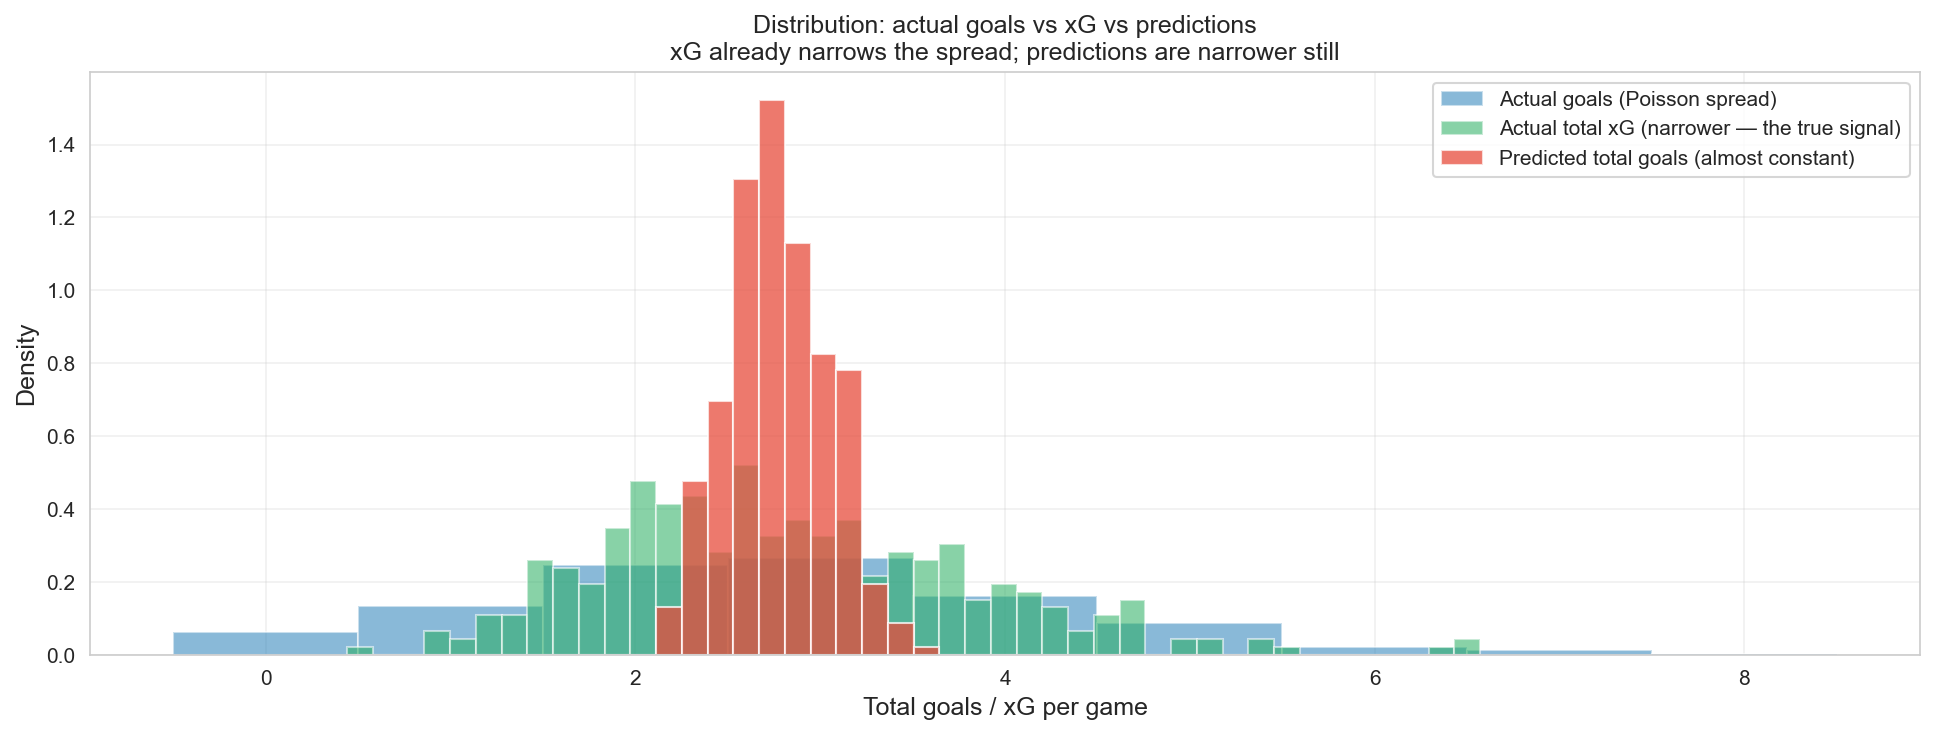

In [12]:
fig, ax = plt.subplots(figsize=(13, 5))
bins_int  = np.arange(-0.5, 9.5, 1)
bins_cont = np.linspace(df[['total_pred','total_xg']].min().min()-0.1,
                        df[['total_pred','total_xg']].max().max()+0.1, 45)

ax.hist(df['total_actual'], bins=bins_int,  alpha=0.55, color='#2980b9',
        label='Actual goals (Poisson spread)', density=True)
ax.hist(df['total_xg'],     bins=bins_cont, alpha=0.55, color='#27ae60',
        label='Actual total xG (narrower — the true signal)', density=True)
ax.hist(df['total_pred'],   bins=bins_cont, alpha=0.75, color='#e74c3c',
        label='Predicted total goals (almost constant)', density=True)
ax.set_xlabel('Total goals / xG per game', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution: actual goals vs xG vs predictions\n'
             'xG already narrows the spread; predictions are narrower still', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/postmortem_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Weekly MAE — Season Trend

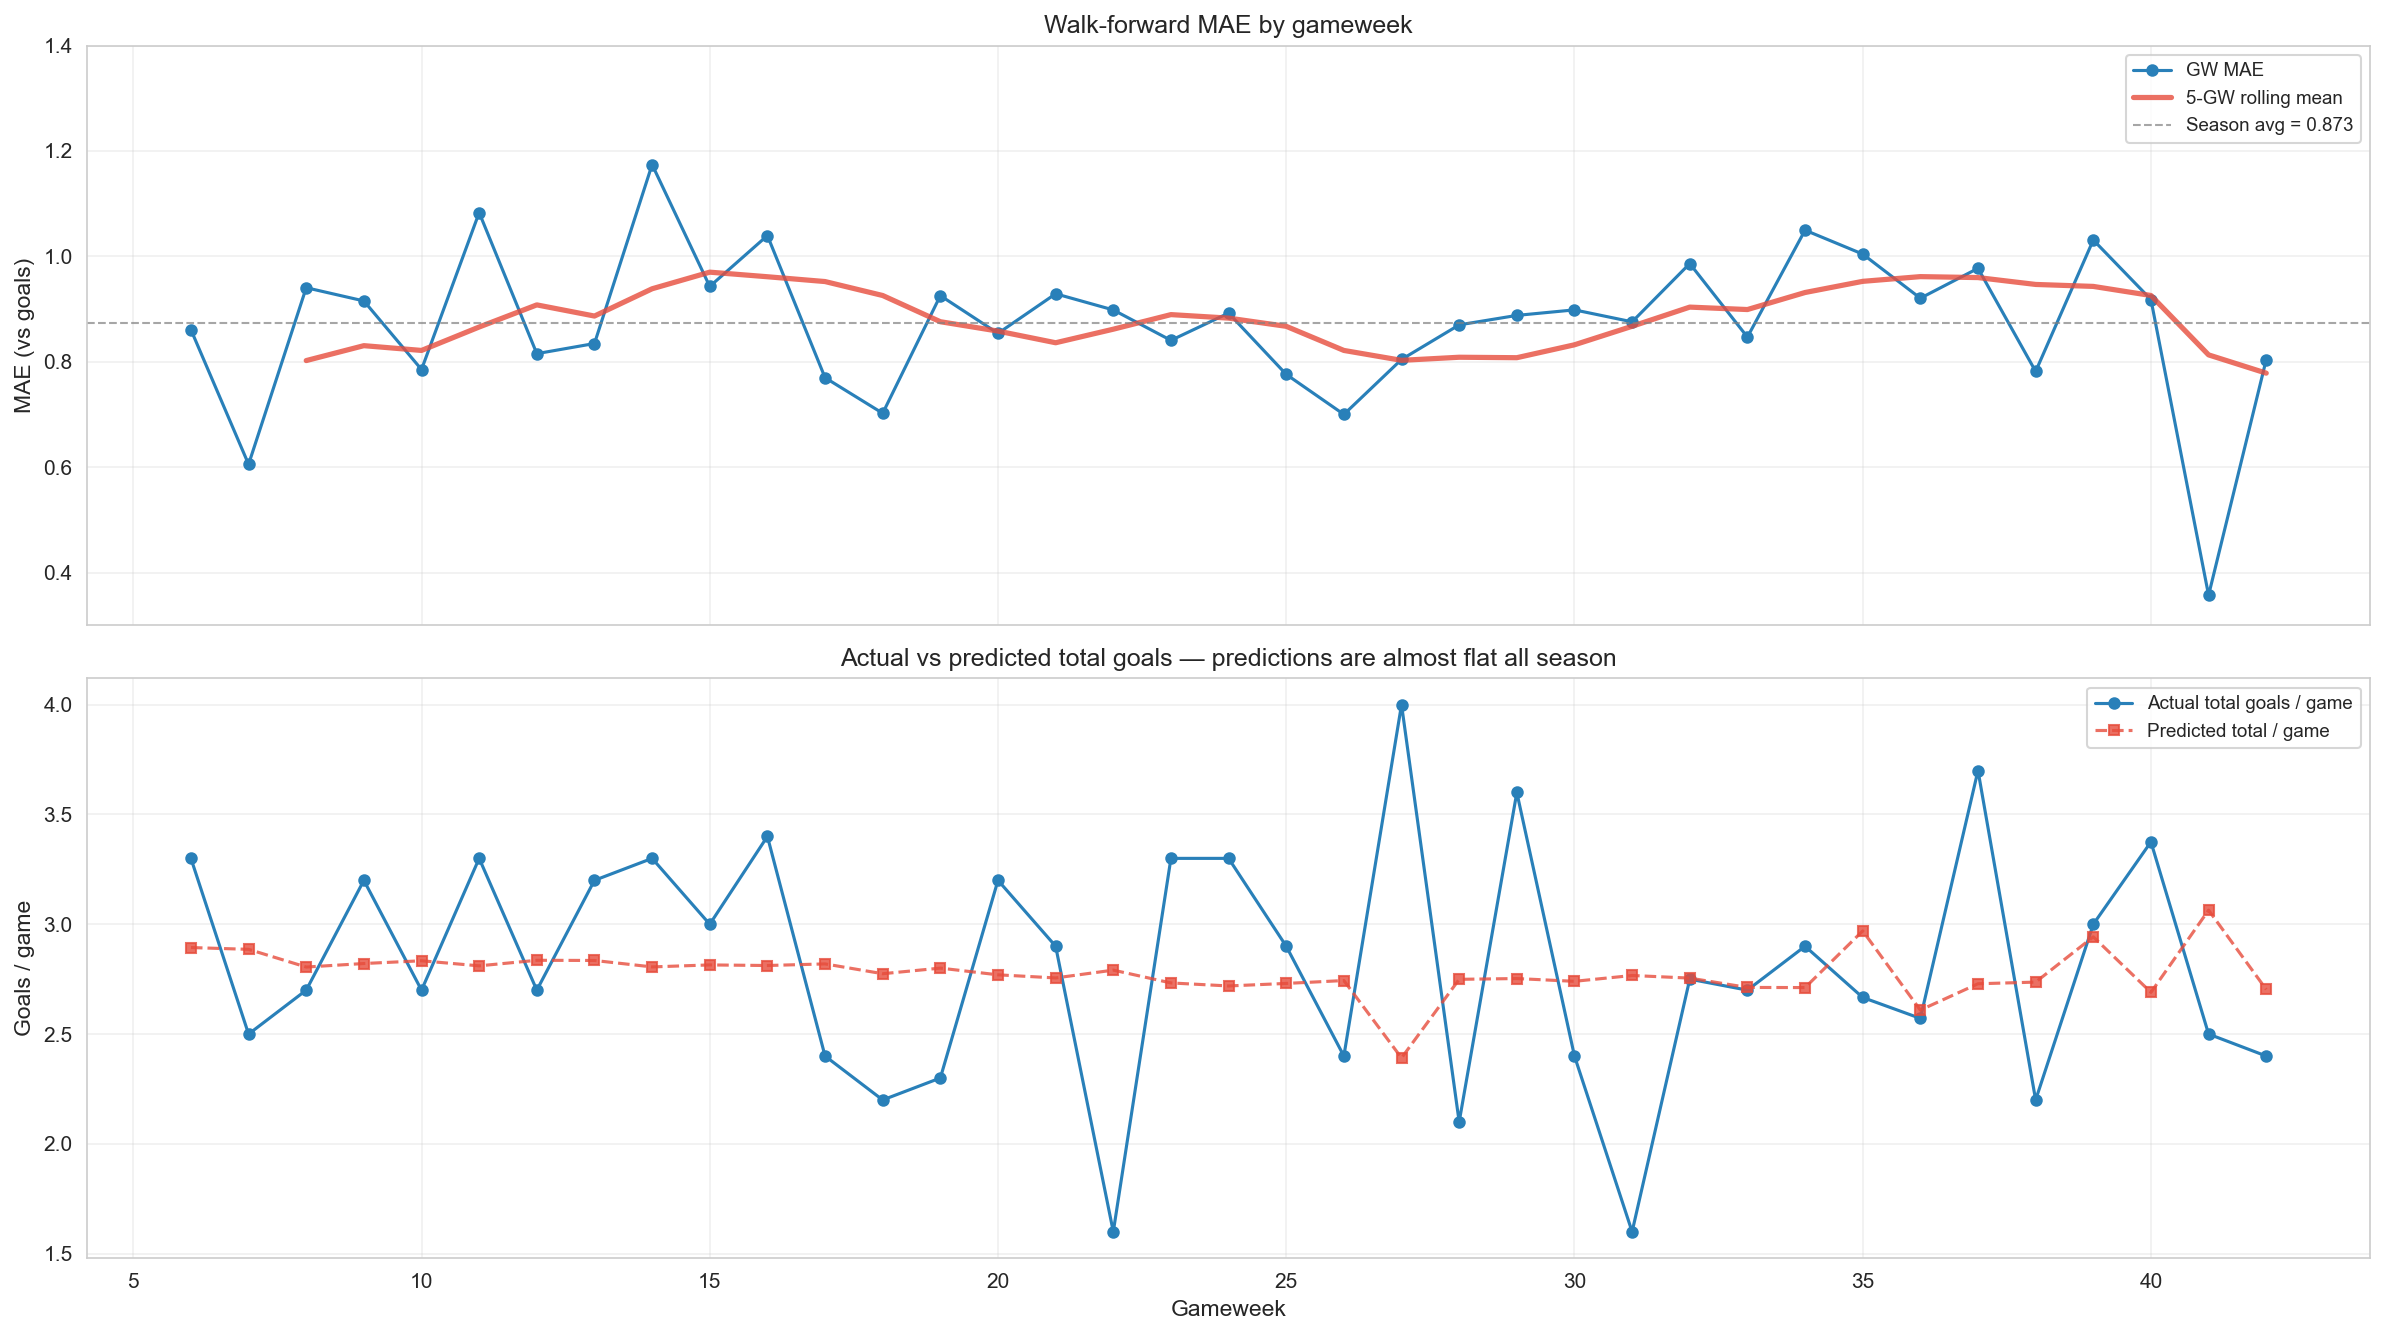

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

ax = axes[0]
ax.plot(gw_acc['gw'], gw_acc['mae'], 'o-', color='#2980b9', lw=1.5, markersize=5, label='GW MAE')
rolling_mae = gw_acc['mae'].rolling(5, min_periods=3).mean()
ax.plot(gw_acc['gw'], rolling_mae, '-', color='#e74c3c', lw=2.5, alpha=0.8, label='5-GW rolling mean')
ax.axhline(gw_acc['mae'].mean(), color='gray', linestyle='--', lw=1, alpha=0.7,
           label=f'Season avg = {gw_acc["mae"].mean():.3f}')
ax.set_ylabel('MAE (vs goals)', fontsize=11)
ax.set_title('Walk-forward MAE by gameweek', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim(0.3, 1.4)

ax2 = axes[1]
ax2.plot(gw_acc['gw'], gw_acc['total_actual'],    'o-',  color='#2980b9', lw=1.5, markersize=5,
         label='Actual total goals / game')
ax2.plot(gw_acc['gw'], gw_acc['total_predicted'], 's--', color='#e74c3c', lw=1.5, markersize=5, alpha=0.8,
         label='Predicted total / game')
ax2.set_xlabel('Gameweek', fontsize=11)
ax2.set_ylabel('Goals / game', fontsize=11)
ax2.set_title('Actual vs predicted total goals — predictions are almost flat all season', fontsize=12)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/postmortem_weekly_mae.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. MAE by Match Goal Total — High-Scoring Game Failure

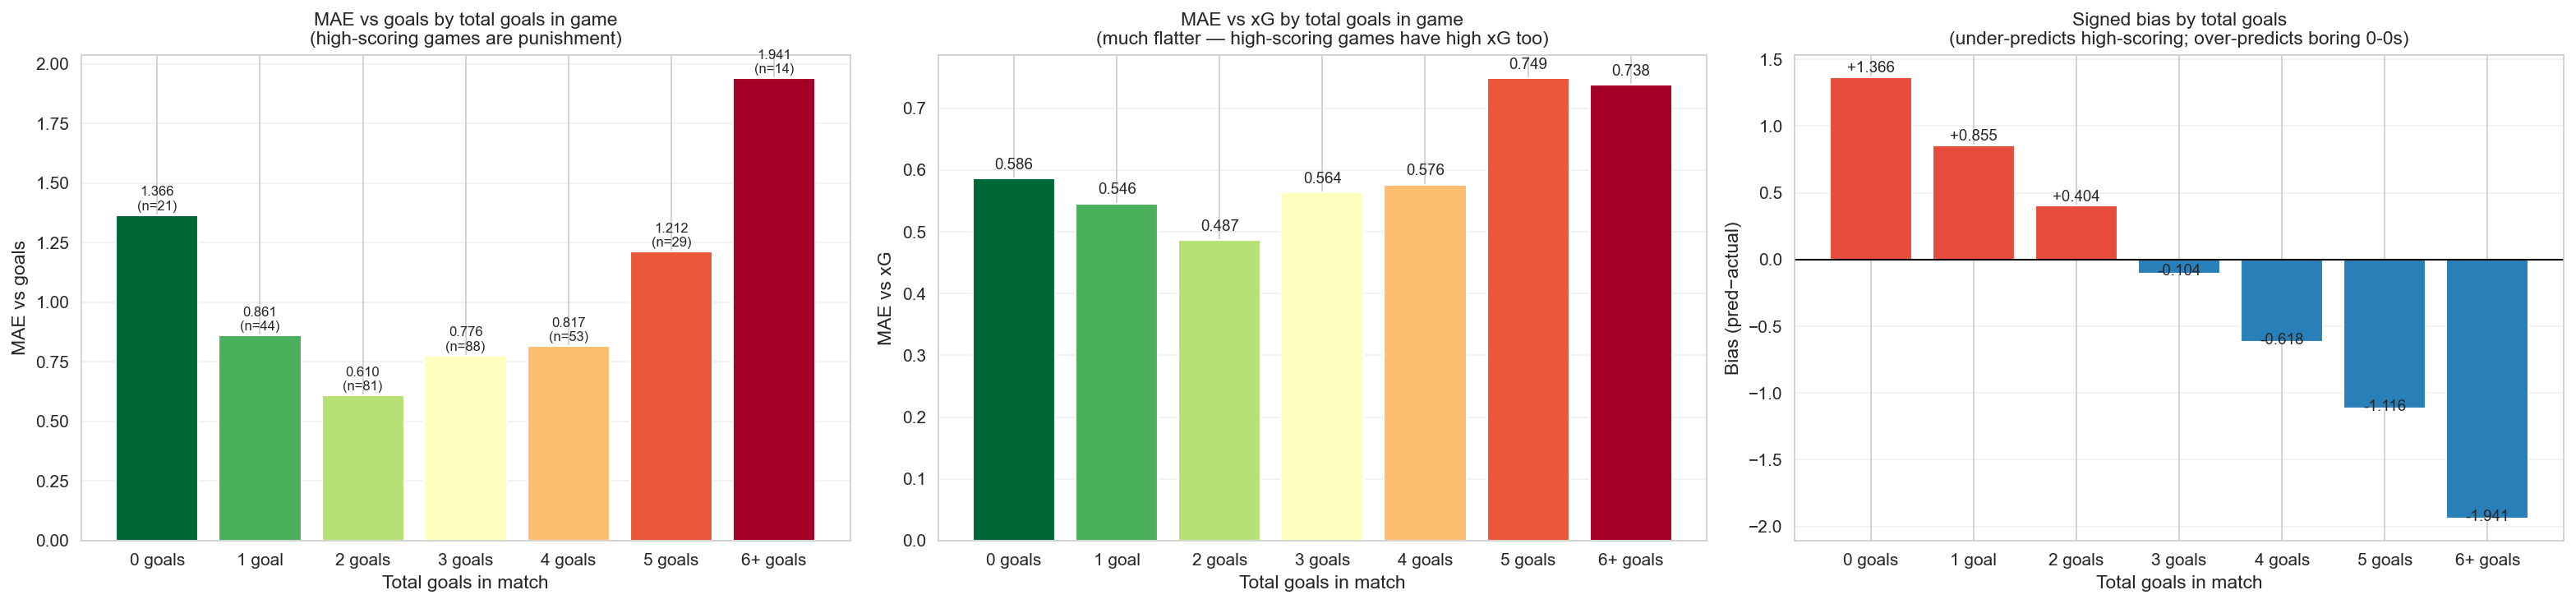

  bucket  n  mae_goals   mae_xg      bias
 0 goals 21   1.366432 0.586062  1.366432
  1 goal 44   0.861497 0.546032  0.855397
 2 goals 81   0.610084 0.486694  0.403623
 3 goals 88   0.776418 0.563570 -0.104375
 4 goals 53   0.817394 0.576220 -0.617926
 5 goals 29   1.212447 0.748893 -1.115567
6+ goals 14   1.940876 0.738175 -1.940876


In [14]:
buckets = [
    ('0 goals',  df['total_actual'] == 0),
    ('1 goal',   df['total_actual'] == 1),
    ('2 goals',  df['total_actual'] == 2),
    ('3 goals',  df['total_actual'] == 3),
    ('4 goals',  df['total_actual'] == 4),
    ('5 goals',  df['total_actual'] == 5),
    ('6+ goals', df['total_actual'] >= 6),
]
bucket_rows = []
for label, mask in buckets:
    sub = df[mask]
    if not len(sub): continue
    mae_g  = pd.concat([sub['home_error'],   sub['away_error']]).mean()
    mae_x  = pd.concat([sub['home_xg_abs'],  sub['away_xg_abs']]).mean()
    bias_g = pd.concat([sub['home_bias'],    sub['away_bias']]).mean()
    bucket_rows.append({'bucket':label,'n':len(sub),'mae_goals':mae_g,'mae_xg':mae_x,'bias':bias_g})
bdf = pd.DataFrame(bucket_rows)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
cmap   = plt.cm.RdYlGn_r
colors = [cmap(i/(len(bdf)-1)) for i in range(len(bdf))]

ax = axes[0]
bars = ax.bar(bdf['bucket'], bdf['mae_goals'], color=colors, edgecolor='white')
for bar, row in zip(bars, bdf.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{row.mae_goals:.3f}\n(n={row.n})', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Total goals in match', fontsize=11); ax.set_ylabel('MAE vs goals', fontsize=11)
ax.set_title('MAE vs goals by total goals in game\n(high-scoring games are punishment)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bars2 = ax2.bar(bdf['bucket'], bdf['mae_xg'], color=colors, edgecolor='white')
for bar, row in zip(bars2, bdf.itertuples()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{row.mae_xg:.3f}', ha='center', va='bottom', fontsize=9)
ax2.set_xlabel('Total goals in match', fontsize=11); ax2.set_ylabel('MAE vs xG', fontsize=11)
ax2.set_title('MAE vs xG by total goals in game\n(much flatter — high-scoring games have high xG too)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[2]
bias_colors = ['#e74c3c' if b > 0 else '#2980b9' for b in bdf['bias']]
bars3 = ax3.bar(bdf['bucket'], bdf['bias'], color=bias_colors, edgecolor='white')
ax3.axhline(0, color='black', lw=1)
for bar, row in zip(bars3, bdf.itertuples()):
    ax3.text(bar.get_x()+bar.get_width()/2,
             row.bias + (0.01 if row.bias >= 0 else -0.04),
             f'{row.bias:+.3f}', ha='center', va='bottom', fontsize=9)
ax3.set_xlabel('Total goals in match', fontsize=11); ax3.set_ylabel('Bias (pred−actual)', fontsize=11)
ax3.set_title('Signed bias by total goals\n(under-predicts high-scoring; over-predicts boring 0-0s)', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/postmortem_goals_bucket.png', dpi=150, bbox_inches='tight')
plt.show()
print(bdf.to_string(index=False))

## 10. Home vs Away Bias

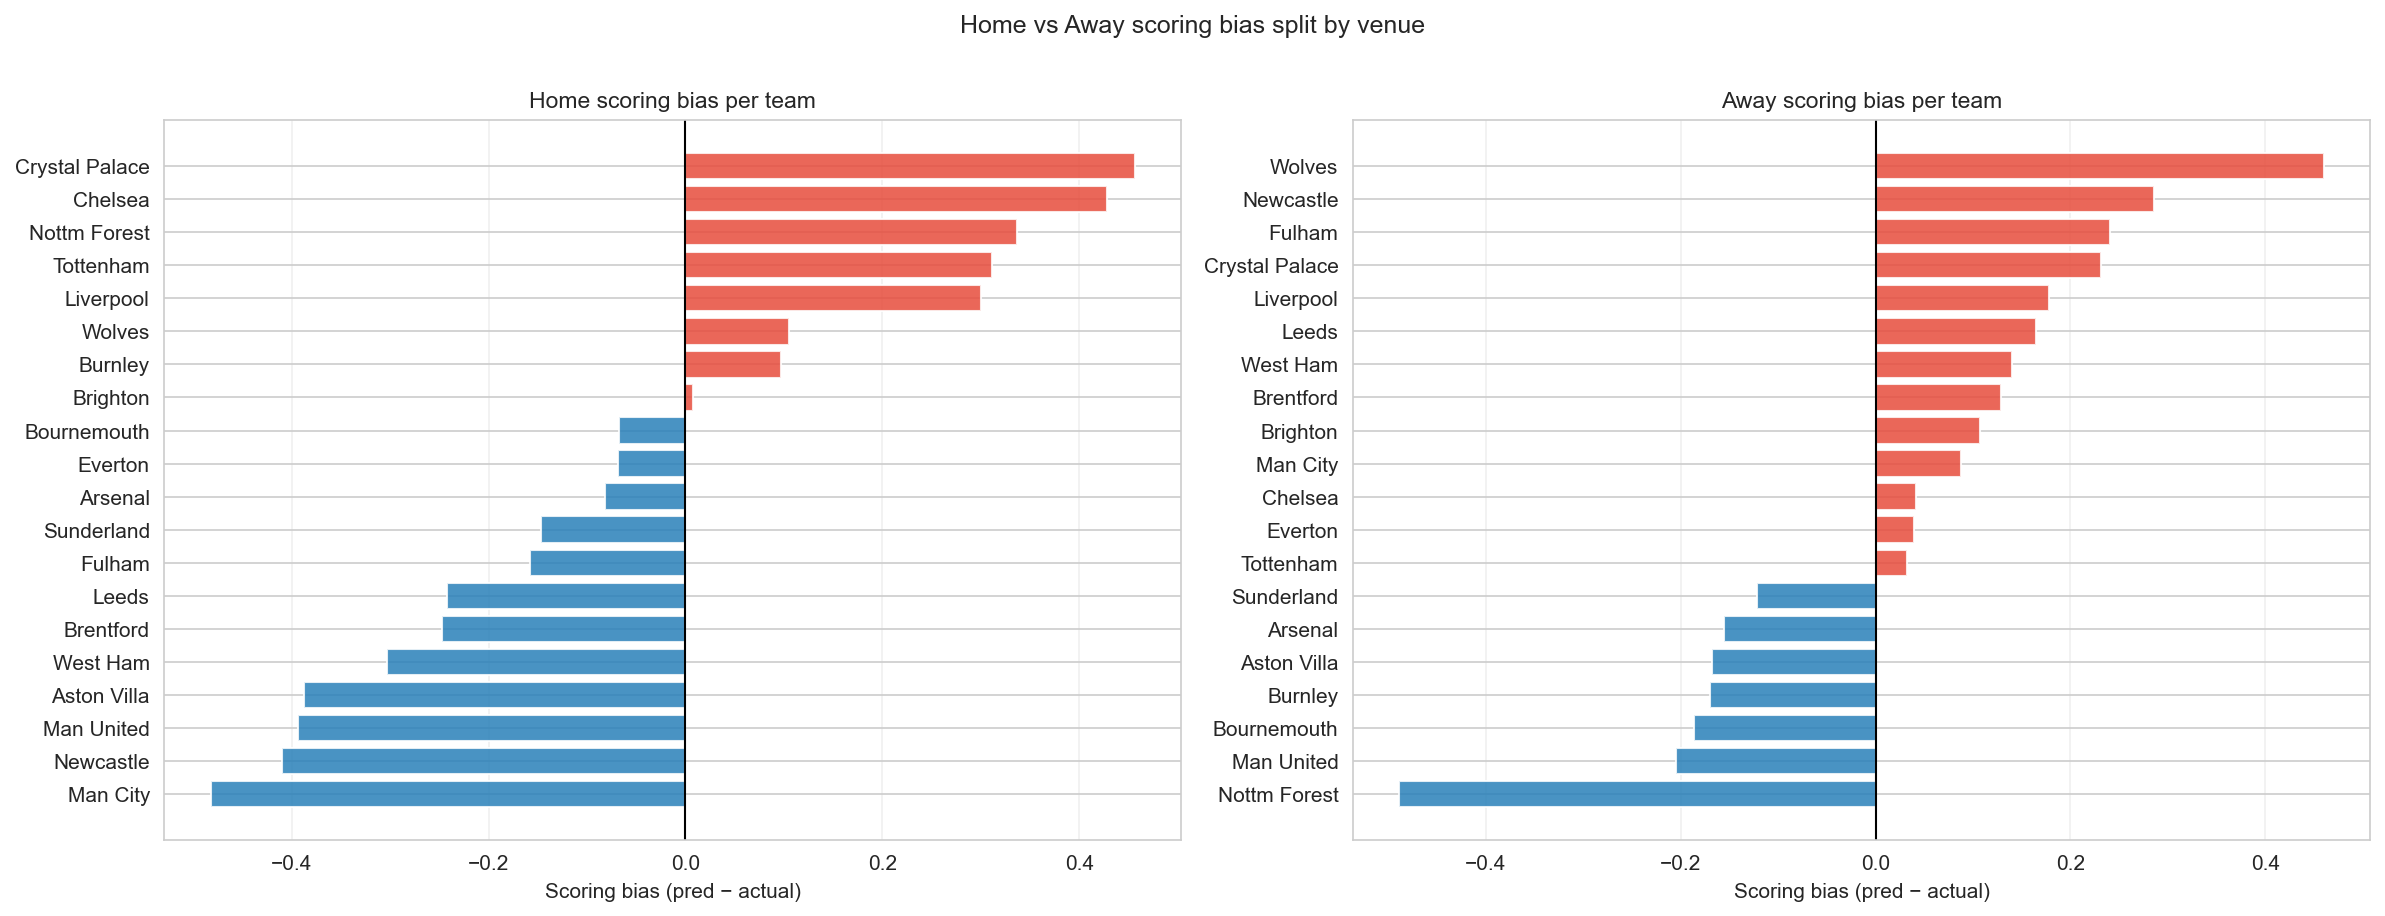

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

home_bias_team = df.groupby('home_team')['home_bias'].mean().sort_values()
away_bias_team = df.groupby('away_team')['away_bias'].mean().sort_values()

for ax, bias, title in [
    (axes[0], home_bias_team, 'Home scoring bias per team'),
    (axes[1], away_bias_team, 'Away scoring bias per team'),
]:
    cols = ['#e74c3c' if b > 0 else '#2980b9' for b in bias]
    ax.barh(bias.index, bias.values, color=cols, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('Scoring bias (pred − actual)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Home vs Away scoring bias split by venue', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('outputs/postmortem_home_away_bias.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Manual Prior Quality — Where Were the Priors Wrong?

In [16]:
sys.path.insert(0, str(NOTEBOOK_DIR.parent))
from premier_league.manual_priors import MANUAL_ATT_PRIORS, MANUAL_DEF_PRIORS

prior_df = pd.DataFrame({
    'team':          list(MANUAL_ATT_PRIORS.keys()),
    'att_prior_mu':  [v[0] for v in MANUAL_ATT_PRIORS.values()],
    'att_prior_sig': [v[1] for v in MANUAL_ATT_PRIORS.values()],
    'def_prior_mu':  [MANUAL_DEF_PRIORS[t][0] for t in MANUAL_ATT_PRIORS.keys()],
    'def_prior_sig': [MANUAL_DEF_PRIORS[t][1] for t in MANUAL_ATT_PRIORS.keys()],
}).set_index('team')

pva = prior_df.join(team_stats[['sc_xg','sc_actual','sc_bias','sc_xg_bias','xg_luck',
                                 'co_xg','co_actual','co_bias']]).sort_values('att_prior_mu')
pva[['att_prior_mu','att_prior_sig','sc_xg','sc_actual','sc_xg_bias','sc_bias','xg_luck']]

,att_prior_mu,att_prior_sig,sc_xg,sc_actual,sc_xg_bias,sc_bias,xg_luck
team,,,,,,,
Sunderland,-0.5858,0.6,1.020,1.091,-0.063,-0.134,0.071
Burnley,-0.4338,0.6,0.861,1.000,0.099,-0.040,0.139
Everton,-0.1408,0.4,1.199,1.242,0.027,-0.016,0.043
Leeds,-0.1358,0.6,1.515,1.364,-0.196,-0.045,-0.151
Wolves,-0.1268,0.4,0.943,0.727,0.073,0.288,-0.215
West Ham,-0.1148,0.4,1.247,1.242,-0.079,-0.075,-0.005
Fulham,-0.0628,0.4,1.302,1.242,-0.013,0.047,-0.060
Nottm Forest,-0.0358,0.4,1.248,1.303,-0.009,-0.064,0.055
Man United,-0.0218,0.4,1.673,1.909,-0.061,-0.296,0.236


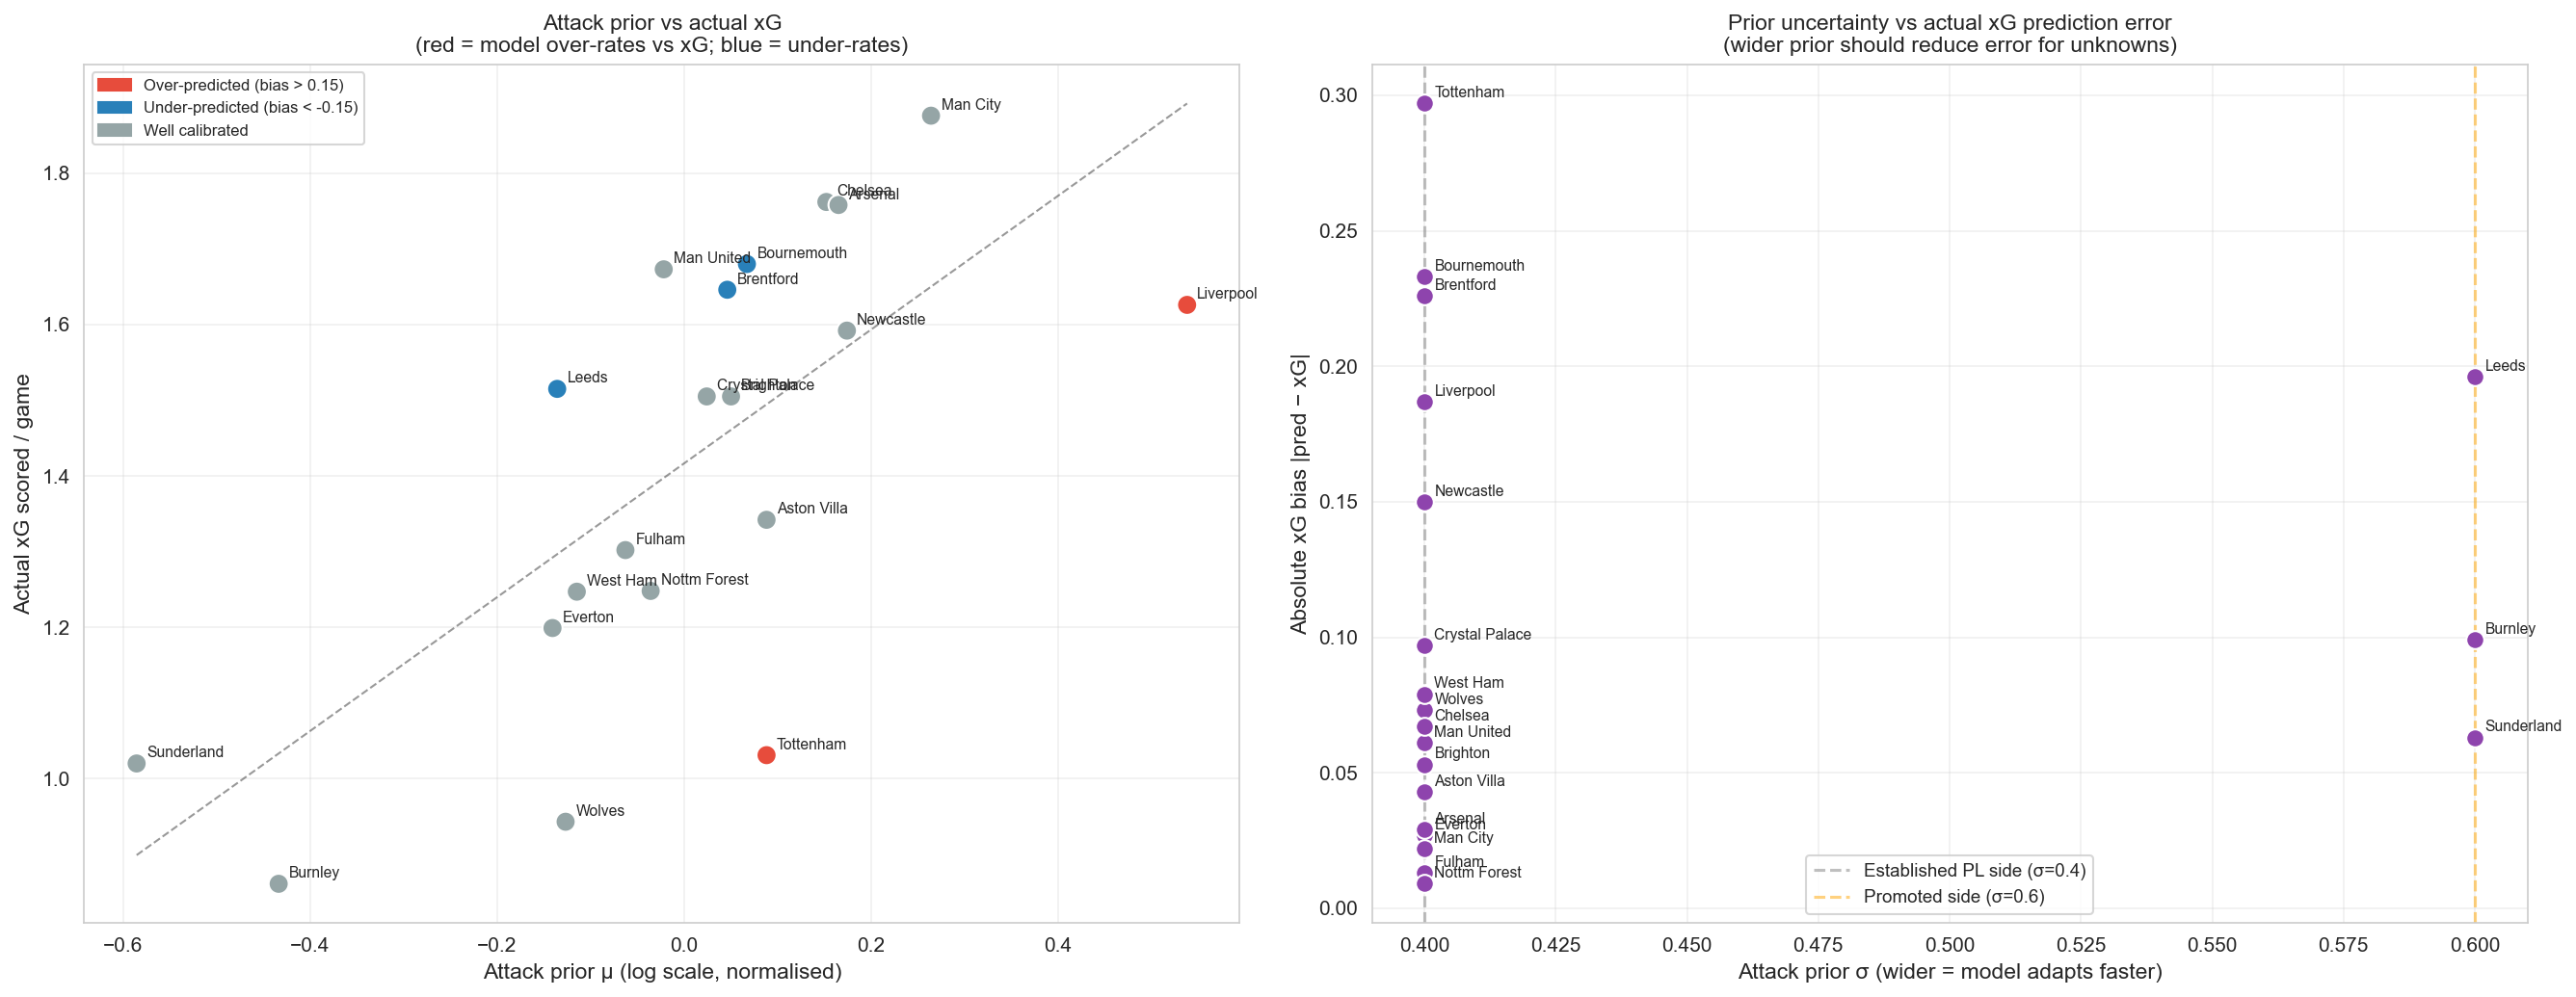

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
pva_plot = pva.copy()

# Left: attack prior vs actual xG (primary)
ax = axes[0]
sc_cols = ['#e74c3c' if b > 0.15 else ('#2980b9' if b < -0.15 else '#95a5a6')
           for b in pva_plot['sc_xg_bias']]
ax.scatter(pva_plot['att_prior_mu'], pva_plot['sc_xg'], s=100, c=sc_cols, edgecolors='white', zorder=3)
for team, row in pva_plot.iterrows():
    ax.annotate(team, (row['att_prior_mu'], row['sc_xg']),
                textcoords='offset points', xytext=(5, 3), fontsize=7.5)
m2, b2 = np.polyfit(pva_plot['att_prior_mu'], pva_plot['sc_xg'], 1)
xs = np.linspace(pva_plot['att_prior_mu'].min(), pva_plot['att_prior_mu'].max(), 100)
ax.plot(xs, m2*xs+b2, 'k--', alpha=0.4, lw=1)
ax.set_xlabel('Attack prior μ (log scale, normalised)', fontsize=11)
ax.set_ylabel('Actual xG scored / game', fontsize=11)
ax.set_title('Attack prior vs actual xG\n(red = model over-rates vs xG; blue = under-rates)', fontsize=11)
red_p  = mpatches.Patch(color='#e74c3c', label='Over-predicted (bias > 0.15)')
blue_p = mpatches.Patch(color='#2980b9', label='Under-predicted (bias < -0.15)')
grey_p = mpatches.Patch(color='#95a5a6', label='Well calibrated')
ax.legend(handles=[red_p, blue_p, grey_p], fontsize=8); ax.grid(alpha=0.3)

# Right: prior sigma vs absolute xG bias
ax2 = axes[1]
ax2.scatter(pva_plot['att_prior_sig'], pva_plot['sc_xg_bias'].abs(),
            s=80, color='#8e44ad', edgecolors='white', zorder=3)
for team, row in pva_plot.iterrows():
    ax2.annotate(team, (row['att_prior_sig'], abs(row['sc_xg_bias'])),
                 textcoords='offset points', xytext=(5, 3), fontsize=7.5)
ax2.axvline(0.4, color='gray', linestyle='--', alpha=0.5, label='Established PL side (σ=0.4)')
ax2.axvline(0.6, color='orange', linestyle='--', alpha=0.5, label='Promoted side (σ=0.6)')
ax2.set_xlabel('Attack prior σ (wider = model adapts faster)', fontsize=11)
ax2.set_ylabel('Absolute xG bias |pred − xG|', fontsize=11)
ax2.set_title('Prior uncertainty vs actual xG prediction error\n(wider prior should reduce error for unknowns)', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/postmortem_prior_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Worst Individual Match Predictions

In [18]:
df['match_label'] = 'GW' + df['gw'].astype(str) + ': ' + df['home_team'] + ' vs ' + df['away_team']
df['total_error']  = df['home_error'] + df['away_error']
df['scoreline']    = df['home_actual'].astype(int).astype(str) + '–' + df['away_actual'].astype(int).astype(str)
df['pred_line']    = df['home_predicted'].round(2).astype(str) + '–' + df['away_predicted'].round(2).astype(str)
df['xg_line']      = df['home_xg'].round(2).astype(str) + '–' + df['away_xg'].round(2).astype(str)

worst = df.nlargest(15, 'total_error')[[
    'match_label','scoreline','pred_line','xg_line',
    'total_actual','total_xg','total_pred','total_error'
]].rename(columns={
    'match_label':'Match','scoreline':'Result','pred_line':'Predicted',
    'xg_line':'xG','total_actual':'Goals','total_xg':'Total xG',
    'total_pred':'Pred total','total_error':'Error'
})
worst['Goals']      = worst['Goals'].astype(int)
worst['Error']      = worst['Error'].round(3)
worst['Total xG']   = worst['Total xG'].round(2)
worst['Pred total'] = worst['Pred total'].round(2)
worst

,Match,Result,Predicted,xG,Goals,Total xG,Pred total,Error
84,GW14: Fulham vs Man City,4–5,1.17–1.54,0.91–2.17,9,3.08,2.72,6.285
106,GW16: Man United vs Bournemouth,4–4,1.71–1.29,3.4–1.94,8,5.34,3.00,5.004
286,GW36: Sunderland vs Nottm Forest,0–5,1.09–1.14,0.7–1.1,5,1.80,2.23,4.952
269,GW34: Aston Villa vs Sunderland,4–3,1.46–0.89,2.84–1.73,7,4.57,2.34,4.655
82,GW14: Brighton vs Aston Villa,3–4,1.43–1.08,2.21–2.41,7,4.62,2.51,4.490
66,GW12: Liverpool vs Nottm Forest,0–3,2.28–1.0,1.93–1.58,3,3.51,3.28,4.288
224,GW29: Burnley vs Brentford,3–4,0.98–1.74,0.97–2.25,7,3.22,2.72,4.284
158,GW21: Newcastle vs Leeds,4–3,1.68–1.12,2.43–1.89,7,4.32,2.80,4.202
227,GW29: Liverpool vs West Ham,5–2,2.11–0.91,1.84–1.86,7,3.70,3.02,3.977
50,GW11: Aston Villa vs Bournemouth,4–0,1.29–1.16,1.7–1.61,4,3.31,2.45,3.873


## 13. Summary — Key Findings for Substack & 2026-27

In [19]:
mae_g  = pd.concat([df['home_error'],   df['away_error']]).mean()
mae_x  = pd.concat([df['home_xg_abs'], df['away_xg_abs']]).mean()
noise  = pd.concat([df['home_luck'].abs(), df['away_luck'].abs()]).mean()
corr_g, pval_g = spearmanr(team_stats['sc_actual'], team_stats['sc_bias'])
corr_x, pval_x = spearmanr(team_stats['sc_xg'],     team_stats['sc_xg_bias'])
r_rank_xg, _ = spearmanr(team_stats['sc_xg'], team_stats['sc_pred'])

print('=== 2025-26 POST-MORTEM ===')
print()
print('━━ OVERALL ACCURACY ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  MAE vs goals (skill + luck):   {mae_g:.4f}')
print(f'  MAE vs xG   (skill only):      {mae_x:.4f}')
print(f'  Irreducible Poisson noise:     {noise:.4f}  (avg |goals − xG| per team-game)')
print(f'  MAE gap explained by luck:     {mae_g - mae_x:.4f}  ({(mae_g-mae_x)/mae_g:.0%} of total error)')
print()
print('━━ WHAT THE MODEL DOES WELL ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Team attack ranking (vs xG):   Spearman r = {r_rank_xg:.3f}  — model correctly orders teams')
print(f'  Direction accuracy vs xG:      {dir_xg:.1%}  — picks correct xG favourite most of the time')
print(f'  League-level calibration:      Predicted {avg_pred:.3f} vs xG {avg_xg:.3f} total/game  (well calibrated)')
print(f'  Home bias:                     {df["home_bias"].mean():+.4f}  |  Away bias: {df["away_bias"].mean():+.4f}  (near-zero)')
print()
print('━━ WHERE THE MODEL IS WEAK ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  1. VARIANCE COMPRESSION (critical)')
print(f'     Pred std = {df["home_predicted"].std():.3f} (home), {df["away_predicted"].std():.3f} (away)')
print(f'     xG std   = {df["home_xg"].std():.3f} (home), {df["away_xg"].std():.3f} (away)')
print(f'     Goals std= {df["home_actual"].std():.3f} (home), {df["away_actual"].std():.3f} (away)')
print(f'     Predictions are ~{df["total_actual"].std()/df["total_pred"].std():.1f}× too narrow. Priors too tight.')
print()
print(f'  2. OVERSHRINKAGE (confirmed)')
print(f'     Spearman r (scored vs bias, vs xG):   {corr_x:.3f}  (p={pval_x:.4f})')
print(f'     Spearman r (scored vs bias, vs goals): {corr_g:.3f}  (p={pval_g:.4f})')
print(f'     Strong teams underpredicted:')
for t in team_stats.nsmallest(4,'sc_xg_bias').index:
    row = team_stats.loc[t]
    print(f'       {t:<20} xG={row.sc_xg:.3f}  pred={row.sc_pred:.3f}  bias_xg={row.sc_xg_bias:+.3f}  luck={row.xg_luck:+.3f}')
print(f'     Weak teams overpredicted:')
for t in team_stats.nlargest(4,'sc_xg_bias').index:
    row = team_stats.loc[t]
    print(f'       {t:<20} xG={row.sc_xg:.3f}  pred={row.sc_pred:.3f}  bias_xg={row.sc_xg_bias:+.3f}  luck={row.xg_luck:+.3f}')
print()
print(f'  3. HIGH-SCORING GAME FAILURE')
print(f'     MAE vs goals rises sharply for 5+ goal games.')
print(f'     MAE vs xG is flatter — those games genuinely had high xG.')
print(f'     This is partly luck, partly NegBinomial tail not captured by Poisson.')
print()
print('━━ KEY TAKEAWAYS FOR SUBSTACK ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  • The model knows which teams are strong — ranking is solid.')
print('  • The predictions are too compressed to be useful for totals betting.')
print('  • Several teams (e.g. Man United) massively outperformed their xG — luck, not skill.')
print('  • Some teams (e.g. Brighton) underperformed their xG — expect regression.')
print('  • Fix path: wider priors + NegBinomial → more spread + better tail coverage.')

=== 2025-26 POST-MORTEM ===

━━ OVERALL ACCURACY ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE vs goals (skill + luck):   0.8788
  MAE vs xG   (skill only):      0.5695
  Irreducible Poisson noise:     0.7899  (avg |goals − xG| per team-game)
  MAE gap explained by luck:     0.3093  (35% of total error)

━━ WHAT THE MODEL DOES WELL ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Team attack ranking (vs xG):   Spearman r = 0.909  — model correctly orders teams
  Direction accuracy vs xG:      70.0%  — picks correct xG favourite most of the time
  League-level calibration:      Predicted 2.776 vs xG 2.833 total/game  (well calibrated)
  Home bias:                     -0.0467  |  Away bias: +0.0319  (near-zero)

━━ WHERE THE MODEL IS WEAK ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. VARIANCE COMPRESSION (critical)
     Pred std = 0.356 (home), 0.301 (away)
     xG std   = 0.798 (home), 0.731 (away)
     Goals std= 1.164 (home), 1.061 (away)
     Predictions are ~5.7× too narrow